# Import des librairies et packages

In [1]:
import pandas as pd
import polars as pl
import polars.selectors as cs

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import time

In [2]:
from sklearn.cluster import KMeans

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import label_binarize
from sklearn.model_selection import StratifiedKFold, cross_val_score, learning_curve, train_test_split

import warnings
from sklearn.base import clone


In [3]:
from src.import_.read_file import  read_file, df_dtypes

from src.exploratory.explore_data import show_values_counts_columns, analyse_univariee_qualitative, describe_variables_numeriques, controle_regroupements_modalites, resume_production_pv_positive, separer_variables_quali_bin_quanti, calculer_modes_train

from src.exploratory.plots import plot_pareto_modalites, plot_boxplot_and_hist, plot_target_dpe, plot_dist, boxplot_vs_target, plot_missing_train_test

from src.exploratory.bivariee import taux_energivore_par_modalite, tableau_quali_quali

from src.prepro.nettoyage import nettoyage_metier
from src.prepro.regrouper_modalites import creer_target_dpe_3_classes
from src.prepro.modalite_groupings import MODALITES_GROUPINGS
from src.prepro.regrouper_modalites import appliquer_regroupements_modalites

from src.prepro.prepro_ import split_train_test_polars, elbow_plot, fit_kmeans_pv_train, appliquer_kmeans_pv, colonnes_avec_missing, imputer_apres_selection, separer_colonnes_pipeline, dendrogramme_modalites_vs_target, construire_preprocessor

from src.stats_.stats_ import tester_variables_avec_target

from src.models.models import afficher_classification_report, plot_confusion_matrix, evaluer_lgb_class_weights

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC

In [5]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    balanced_accuracy_score,
    accuracy_score,
    f1_score,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
)

In [6]:
import optuna

from optuna.samplers import TPESampler

optuna.logging.set_verbosity(optuna.logging.WARNING)

CLASSES = ["performant", "intermediaire", "energivore"]

In [7]:
pl.Config.set_tbl_rows(-1)
pl.Config.set_tbl_cols(-1)
pl.Config.set_tbl_width_chars(-1)
pl.Config.set_fmt_str_lengths(100)

polars.config.Config

In [8]:
PATH_DATA = "resources/dpe_hauts_de_france_2025-07-01_to_2025-12-31_half.csv"
TARGET = "etiquette_dpe"
CLASSES_DPE = ["A", "B", "C", "D", "E", "F", "G"]

DPE_COLORS = {
    "A": "#008A4B",
    "B": "#58B957",
    "C": "#C7D93D",
    "D": "#F4E04D",
    "E": "#F5A623",
    "F": "#E85D27",
    "G": "#C62828",
}

RANDOM_STATE = 42

# Lecture et Visualisation des données

In [9]:
data, num_cols, cat_cols = read_file(PATH_DATA, TARGET)
df = data.clone()

### Import des données

Le jeu de données contient **57826 lignes** et **46 colonnes**.

### Réduction de la taille du DataFrame

Taille du DataFrame avant réduction : **37.71 MB**

Taille du DataFrame après réduction : **34.35 MB**

Réduction mémoire : **8.92%**

### Aperçu des données importées

etiquette_dpe,numero_dpe,date_etablissement_dpe,code_region_ban,code_departement_ban,code_postal_ban,code_insee_ban,nom_commune_ban,zone_climatique,classe_altitude,type_batiment,methode_application_dpe,periode_construction,annee_construction,surface_habitable_immeuble,nombre_niveau_immeuble,nombre_appartement,numero_etage_appartement,hauteur_sous_plafond,classe_inertie_batiment,qualite_isolation_enveloppe,qualite_isolation_murs,qualite_isolation_menuiseries,qualite_isolation_plancher_bas,qualite_isolation_plancher_haut_comble_perdu,type_installation_chauffage,type_installation_chauffage_n1,configuration_installation_chauffage_n1,type_generateur_chauffage_principal,type_generateur_n1_installation_n1,type_energie_principale_chauffage,type_energie_generateur_n1_installation_n1,type_emetteur_installation_chauffage_n1,usage_generateur_n1_installation_n1,type_installation_ecs,type_installation_ecs_n1,configuration_installation_ecs_n1,type_generateur_n1_ecs_n1,type_generateur_chauffage_principal_ecs,type_energie_principale_ecs,type_energie_generateur_n1_ecs_n1,usage_generateur_n1_ecs_n1,volume_stockage_generateur_n1_ecs_n1,ventilation_posterieure_2012,type_installation_solaire_n1,production_electricite_pv_kwhep_par_an
str,str,str,u8,u8,u32,u32,str,str,str,str,str,str,f32,f32,f32,f32,f32,f32,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,f32,u8,str,f32
"""C""","""2559E3504406H""","""2025-11-05""",32,59,59320,59286,"""Haubourdin""","""H1a""","""inférieur à 400m""","""maison""","""dpe maison individuelle""","""1948-1974""",null,null,null,null,0.0,2.5,"""Lourde""","""très bonne""","""très bonne""","""bonne""","""très bonne""","""très bonne""",null,"""installation individuelle""","""Installation de chauffage simple""","""Chaudière gaz à condensation après 2015""","""Chaudière gaz à condensation après 2015""","""Gaz naturel""","""Gaz naturel""","""Radiateur monotube sans robinet thermostatique sur réseau individuel eau chaude basse ou moyenne tem…","""chauffage + ecs""",null,"""installation individuelle""","""Un seul système d'ECS sans solaire""","""Chaudière gaz à condensation après 2015""","""Chaudière gaz à condensation après 2015""","""Gaz naturel""","""Gaz naturel""","""chauffage + ecs""",0.0,1,"""Non affecté""",0.0
"""F""","""2559E2432688J""","""2025-07-24""",32,59,59360,59136,"""Le Cateau-Cambrésis""","""H1a""","""inférieur à 400m""","""maison""","""dpe maison individuelle""","""avant 1948""",null,null,null,null,0.0,2.6,"""Lourde""","""insuffisante""","""insuffisante""","""moyenne""","""insuffisante""",null,null,"""installation individuelle""","""Installation de chauffage simple""",null,"""Chaudière gaz à condensation 2001-2015""","""Gaz naturel""","""Gaz naturel""","""Radiateur bitube avec robinet thermostatique sur réseau individuel eau chaude haute température(sup …","""chauffage + ecs""",null,"""installation individuelle""","""Un seul système d'ECS sans solaire""","""Chaudière gaz à condensation 2001-2015""",null,"""Gaz naturel""","""Gaz naturel""","""chauffage + ecs""",0.0,0,"""Non affecté""",0.0
"""C""","""2502E3087497D""","""2025-09-30""",32,2,2170,2558,"""Le Nouvion-en-Thiérache""","""H1a""","""inférieur à 400m""","""appartement""","""dpe appartement individuel""","""1978-1982""",null,512.299988,null,1.0,0.0,2.5,"""Moyenne""","""très bonne""","""insuffisante""","""très bonne""","""insuffisante""",null,"""individuel""","""installation individuelle""","""Installation de chauffage simple""",null,"""Panneau rayonnant électrique NFC, NF** et NF***""","""Électricité""","""Électricité""","""Panneau rayonnant NFC, NF** et NF***""","""chauffage""","""individuel""","""installation individuelle""","""Un seul système d'ECS sans solaire""","""CET sur air ambiant (sur local non chauffé) après 2014""",null,"""Électricité""","""Électricité""","""ecs""",150.0,1,"""Non affecté""",0.0
"""E""","""2502E3013330O""","""2025-09-23""",32,2,2000,2408,"""Laon""","""H1a""","""inférieur à 400m""","""maison"""

### Que vaut notre target ?

etiquette_dpe,Pourcentage
str,f64
"""A""",0.94
"""B""",3.26
"""C""",36.12
"""D""",35.52
"""E""",15.03
"""F""",6.1
"""G""",3.03


In [10]:
df_dtypes(df)

### Les différents types du df

Variables,Types
str,str
"""etiquette_dpe""","""String"""
"""numero_dpe""","""String"""
"""date_etablissement_dpe""","""String"""
"""code_region_ban""","""UInt8"""
"""code_departement_ban""","""UInt8"""
"""code_postal_ban""","""UInt32"""
"""code_insee_ban""","""UInt32"""
"""nom_commune_ban""","""String"""
"""zone_climatique""","""String"""


### Catégorisation des types du df

Type,Nombre,Pourcentage
object,i64,f64
String,33,71.74
UInt8,3,6.52
UInt32,2,4.35
Float32,8,17.39


In [11]:
show_values_counts_columns(df)

### Modalités distinctes et valeurs manquantes par variable

Variable,Nombre de lignes,% valeurs manquantes,Modalités distinctes,% modalités distinctes
str,i64,f64,i64,f64
"""nombre_niveau_immeuble""",57826,76.42,19,0.03
"""surface_habitable_immeuble""",57826,68.46,3858,6.67
"""type_generateur_chauffage_principal_ecs""",57826,67.75,73,0.13
"""type_generateur_chauffage_principal""",57826,67.67,93,0.16
"""qualite_isolation_plancher_haut_comble_perdu""",57826,52.86,4,0.01
"""annee_construction""",57826,51.93,204,0.35
"""nombre_appartement""",57826,50.91,135,0.23
"""type_installation_chauffage""",57826,47.75,3,0.01
"""type_installation_ecs""",57826,47.75,3,0.01


# Première suppression de variables

In [12]:
var_to_drop1 = ["nombre_niveau_immeuble", "surface_habitable_immeuble", "type_generateur_chauffage_principal_ecs", "type_generateur_chauffage_principal", "qualite_isolation_plancher_haut_comble_perdu", "annee_construction", "nombre_appartement", "type_installation_chauffage", "type_installation_ecs", ]

var_const = ["numero_dpe"]

var_dpe = ["methode_application_dpe", "date_etablissement_dpe"]

var_id = ["code_region_ban", "code_departement_ban", "code_postal_ban", "code_insee_ban", "nom_commune_ban"]

var_to_drop = [*var_const, *var_dpe, *var_id]

cat_cols = list(set(cat_cols) - {*var_to_drop, *var_to_drop1})
num_cols = list(set(num_cols) - {*var_to_drop, *var_to_drop1})

In [13]:
df = df.drop(var_to_drop1)

In [14]:
CAT_VAR_TO_ANALYSE = ["zone_climatique", "type_batiment", "type_energie_principale_chauffage"]

NUM_VAR_TO_ANALYSE = ["numero_etage_appartement", "production_electricite_pv_kwhep_par_an", "hauteur_sous_plafond"]


# Analyse univariée

## Variables catégorielles

In [15]:
analyse_univariee_qualitative(df, col="zone_climatique")

## Analyse univariée : `zone_climatique`


        - Nombre de lignes : **57826**
        - Nombre de modalités distinctes : **8**
        - Pourcentage de valeurs manquantes : **0.0 %**
        

zone_climatique,Pourcentage
str,f64
"""H1a""",99.86
"""H3""",0.05
"""H1b""",0.03
"""H1c""",0.03
"""H2a""",0.01
"""H2c""",0.01
"""H2b""",0.01
"""H2d""",0.0


In [16]:
analyse_univariee_qualitative(df, col="type_energie_principale_chauffage")

## Analyse univariée : `type_energie_principale_chauffage`


        - Nombre de lignes : **57826**
        - Nombre de modalités distinctes : **11**
        - Pourcentage de valeurs manquantes : **0.0 %**
        

type_energie_principale_chauffage,Pourcentage
str,f64
"""Gaz naturel""",53.58
"""Électricité""",31.57
"""Réseau de Chauffage urbain""",7.89
"""Fioul domestique""",3.22
"""Bois – Granulés (pellets) ou briquettes""",1.74
"""Bois – Bûches""",1.49
"""GPL""",0.3
"""Charbon""",0.1
"""Propane""",0.09


In [17]:
var_doublons = ["type_energie_generateur_n1_installation_n1", "type_energie_generateur_n1_ecs_n1"]

var_to_drop = [*var_to_drop, *var_doublons]

In [18]:
df.select(
    [
        pl.len().alias("nb_lignes"),

        (
            pl.col("type_energie_principale_chauffage")
            == pl.col("type_energie_generateur_n1_installation_n1")
        )
        .sum()
        .alias("nb_identiques"),

        (
            pl.col("type_energie_principale_chauffage")
            != pl.col("type_energie_generateur_n1_installation_n1")
        )
        .sum()
        .alias("nb_differentes"),

        pl.col("type_energie_principale_chauffage").null_count()
        .alias("null_principale_chauffage"),

        pl.col("type_energie_generateur_n1_installation_n1").null_count()
        .alias("null_generateur_n1"),
    ]
)

nb_lignes,nb_identiques,nb_differentes,null_principale_chauffage,null_generateur_n1
u32,u32,u32,u32,u32
57826,57522,278,0,26


In [19]:
df.select(
    [
        pl.len().alias("nb_lignes"),

        (
            pl.col("type_energie_principale_ecs")
            == pl.col("type_energie_generateur_n1_ecs_n1")
        )
        .sum()
        .alias("nb_identiques"),

        (
            pl.col("type_energie_principale_ecs")
            != pl.col("type_energie_generateur_n1_ecs_n1")
        )
        .sum()
        .alias("nb_differentes"),

        pl.col("type_energie_principale_ecs").null_count()
        .alias("null_principale_chauffage"),

        pl.col("type_energie_generateur_n1_ecs_n1").null_count()
        .alias("null_generateur_n1"),
    ]
)

nb_lignes,nb_identiques,nb_differentes,null_principale_chauffage,null_generateur_n1
u32,u32,u32,u32,u32
57826,57557,42,0,227


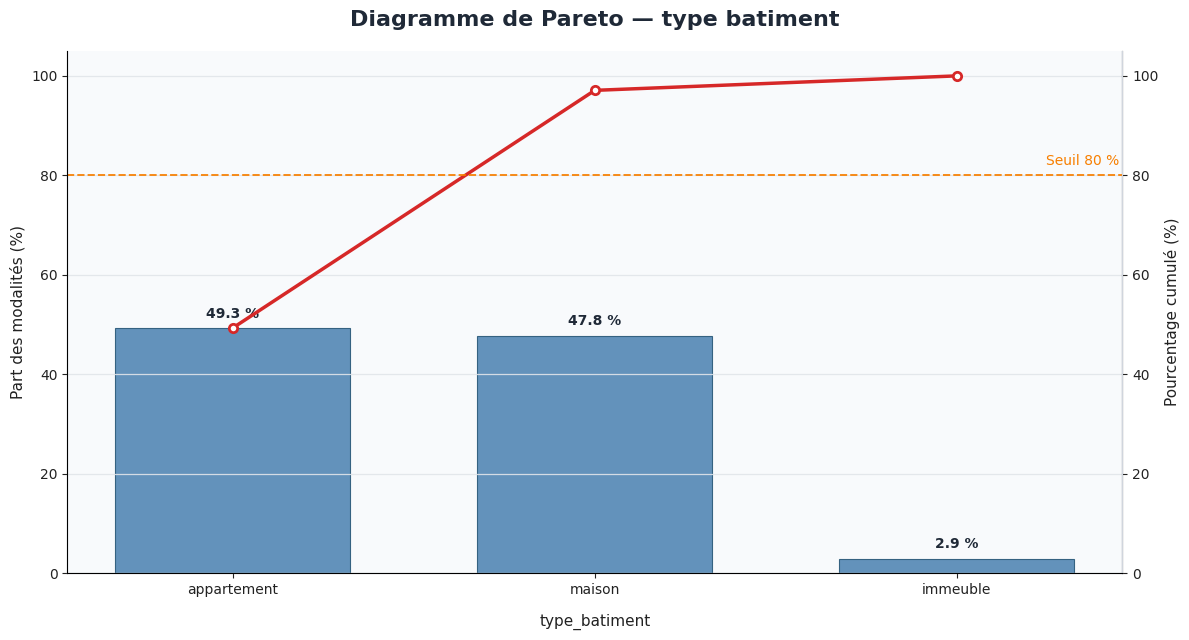

WindowsPath('src/plots/cat/pareto_type_batiment.png')

In [20]:
plot_pareto_modalites(df, col="type_batiment", top_n=10)

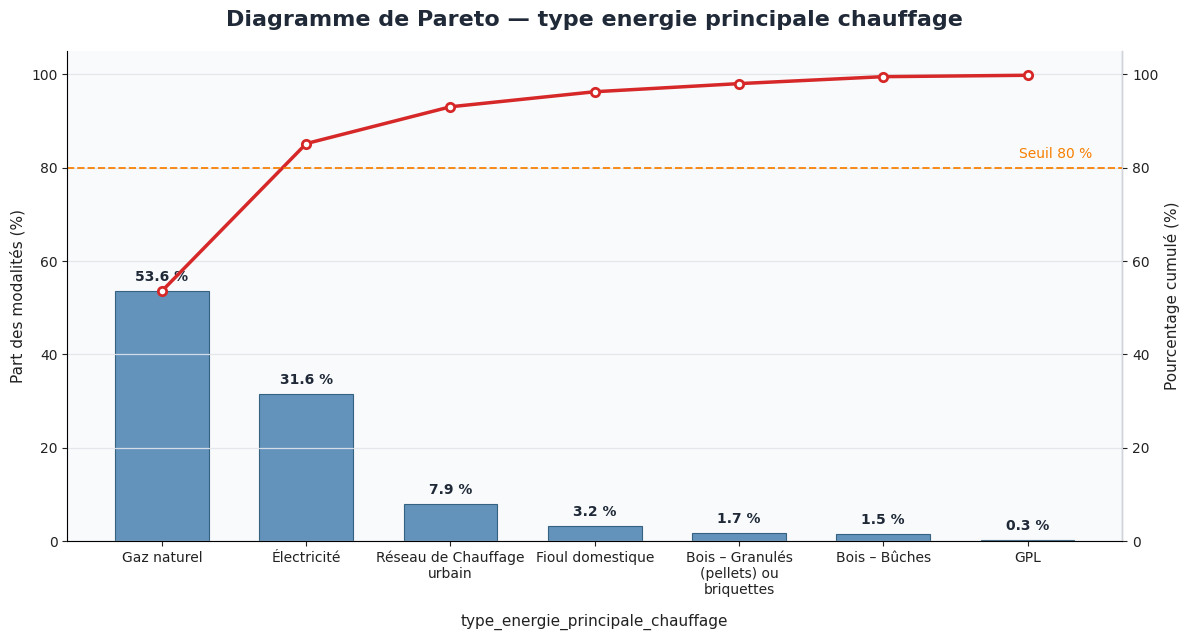

WindowsPath('src/plots/cat/pareto_type_energie_principale_chauffage.png')

In [21]:
plot_pareto_modalites(df, col="type_energie_principale_chauffage", top_n=7)

## Variables numériques

In [22]:
var_binaire = ["ventilation_posterieure_2012"]

num_cols = list(set(num_cols) - {*var_binaire, *var_id})
outlier_cols = describe_variables_numeriques(df, num_cols)


### Resume statistique des variables numériques

colonne,count,missing_count,missing_%,nb_unique,mean,std,min,q1,median,q3,max,iqr,borne_basse,borne_haute,outlier_count,outlier_%
str,i64,i64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64
"""production_electricite_pv_kwhep_par_an""",57826,0,0.0,399,42.724,1980.189,0.0,0.0,0.0,0.0,460380.8125,0.0,0.0,0.0,586,1.01
"""hauteur_sous_plafond""",57826,0,0.0,61,2.562,1.727,1.0,2.5,2.5,2.5,240.0,0.0,2.5,2.5,16546,28.61
"""numero_etage_appartement""",51558,6268,10.84,19,0.15,0.681,-2.0,0.0,0.0,0.0,18.0,0.0,0.0,0.0,3493,6.04
"""volume_stockage_generateur_n1_ecs_n1""",57599,227,0.39,773,93.848,228.659,0.0,0.0,0.0,150.0,10000.0,150.0,-225.0,375.0,827,1.43


In [23]:
num_cols

['production_electricite_pv_kwhep_par_an',
 'hauteur_sous_plafond',
 'numero_etage_appartement',
 'volume_stockage_generateur_n1_ecs_n1']

### Visualisation des variables numériques

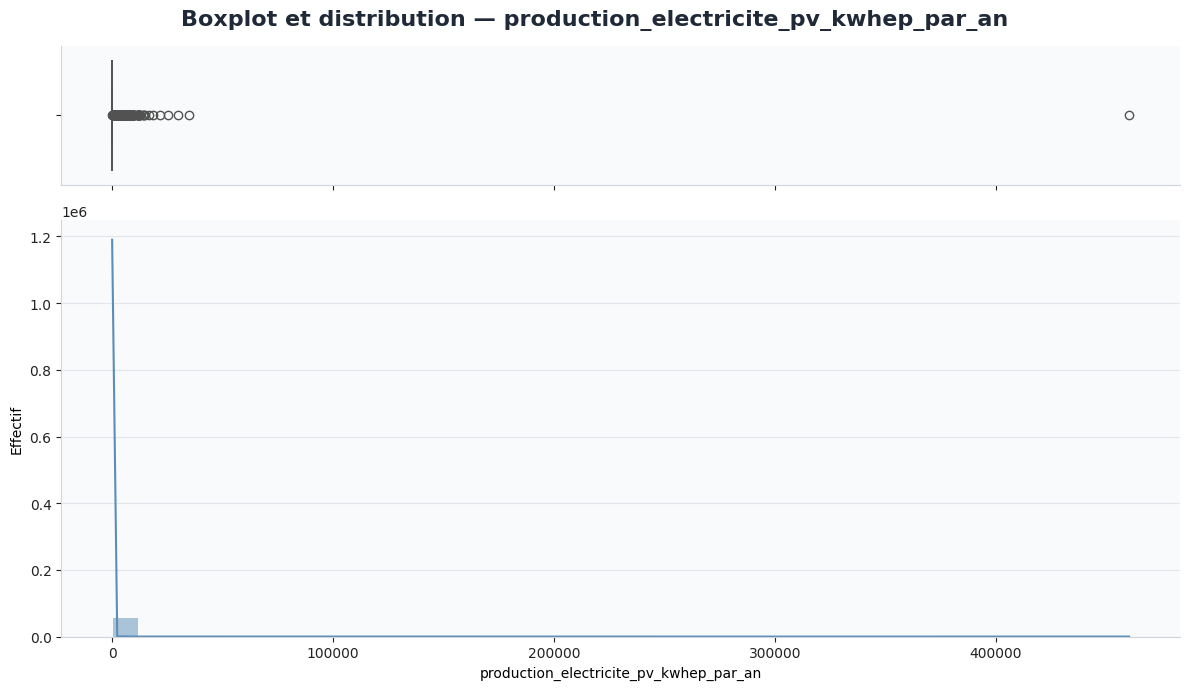

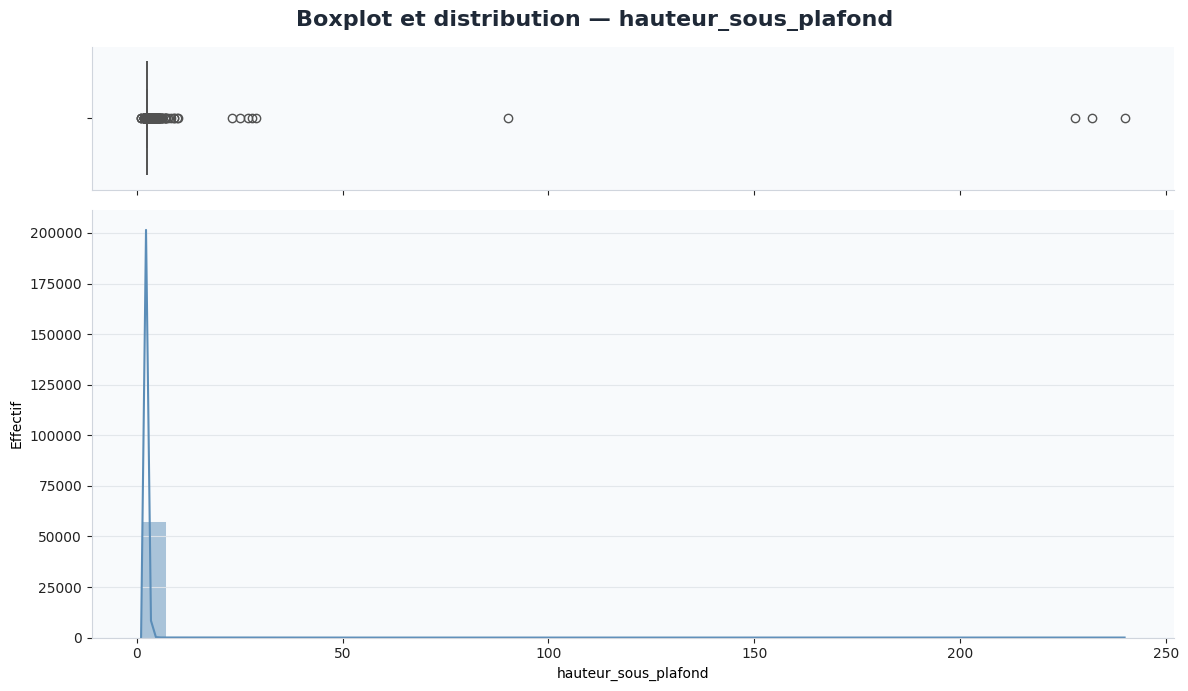

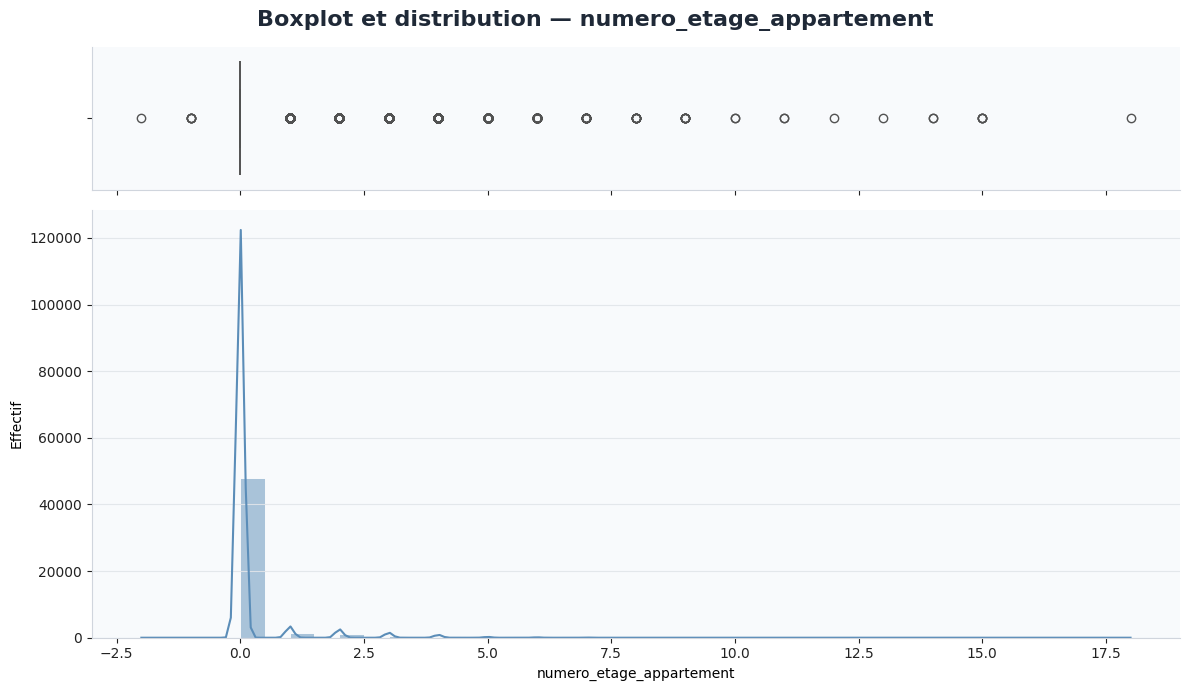

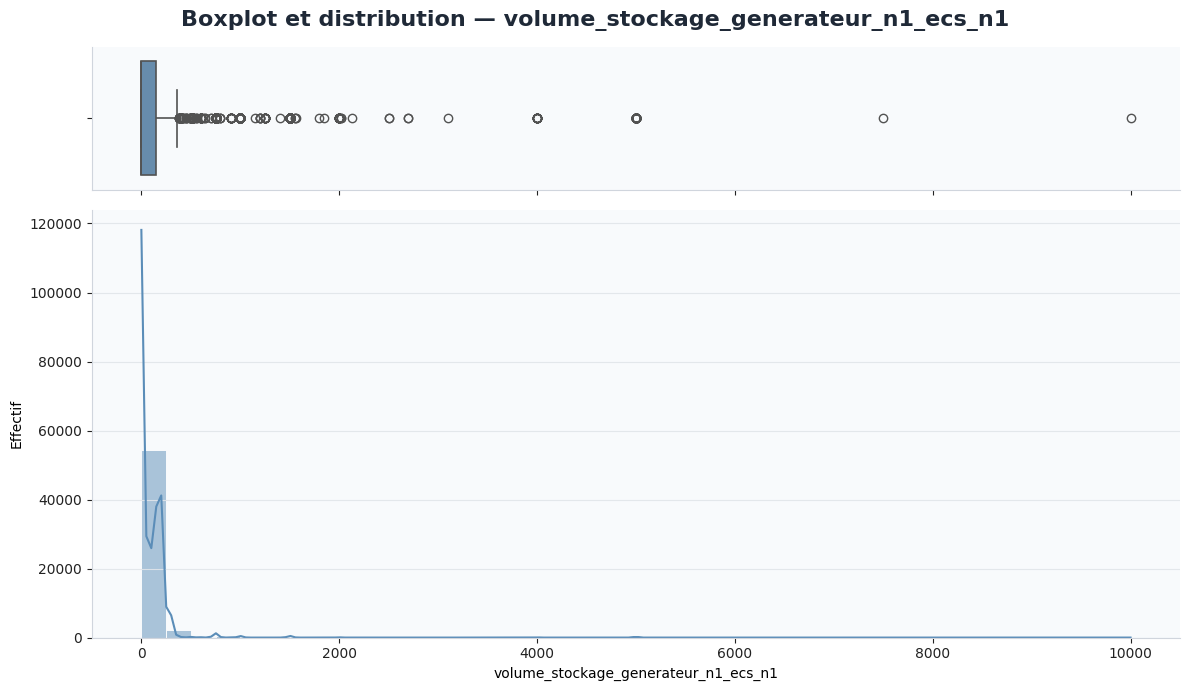

In [24]:
for col in num_cols:
    plot_boxplot_and_hist(df, col)

In [25]:
df["numero_etage_appartement"].value_counts()

numero_etage_appartement,count
f32,u32
3.0,602
11.0,2
-2.0,1
13.0,1
-1.0,5
18.0,1
4.0,347
14.0,2
5.0,96


In [26]:
sum(df["hauteur_sous_plafond"] > 5) + sum(df["hauteur_sous_plafond"] < 1.8)

39

# Un premier nettoyage sur les variables quantitatives avant d'aller plus loin

In [27]:
df = nettoyage_metier(df)

In [28]:
df.shape

(57103, 40)

In [29]:
new_cols_num = ["hauteur_sous_plafond_corrigee"]
var_bianire = [*var_binaire, *["has_PV"]]

num_cols = num_cols + new_cols_num

In [30]:
outlier_cols = describe_variables_numeriques(df, num_cols)

### Resume statistique des variables numériques

colonne,count,missing_count,missing_%,nb_unique,mean,std,min,q1,median,q3,max,iqr,borne_basse,borne_haute,outlier_count,outlier_%
str,i64,i64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64
"""production_electricite_pv_kwhep_par_an""",57103,0,0.0,395,42.656,1989.671,0.0,0.0,0.0,0.0,460380.8125,0.0,0.0,0.0,582,1.02
"""hauteur_sous_plafond""",57103,0,0.0,42,2.558,1.682,1.9,2.5,2.5,2.5,240.0,0.0,2.5,2.5,16417,28.75
"""numero_etage_appartement""",50922,6181,10.82,19,0.15,0.681,-2.0,0.0,0.0,0.0,18.0,0.0,0.0,0.0,3427,6.0
"""volume_stockage_generateur_n1_ecs_n1""",56876,227,0.4,761,77.838,103.867,0.0,0.0,0.0,150.0,5000.0,150.0,-225.0,375.0,137,0.24
"""hauteur_sous_plafond_corrigee""",57103,0,0.0,42,2.545,0.173,1.9,2.5,2.5,2.5,6.0,0.0,2.5,2.5,16417,28.75


### Visualisation de la variavle hauteur_sous_plafond_corrigee

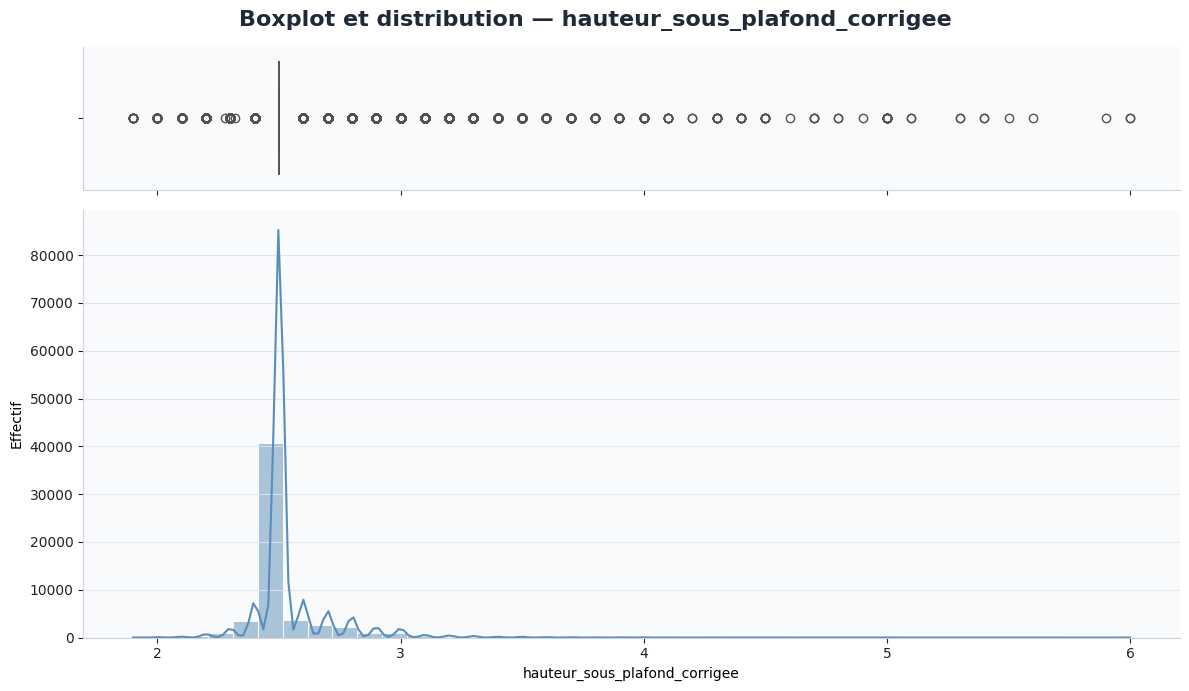

WindowsPath('src/plots/num/boxplot_distribution_hauteur_sous_plafond_corrigee.png')

In [31]:
plot_boxplot_and_hist(df, col="hauteur_sous_plafond_corrigee")

# Visualisation de la target

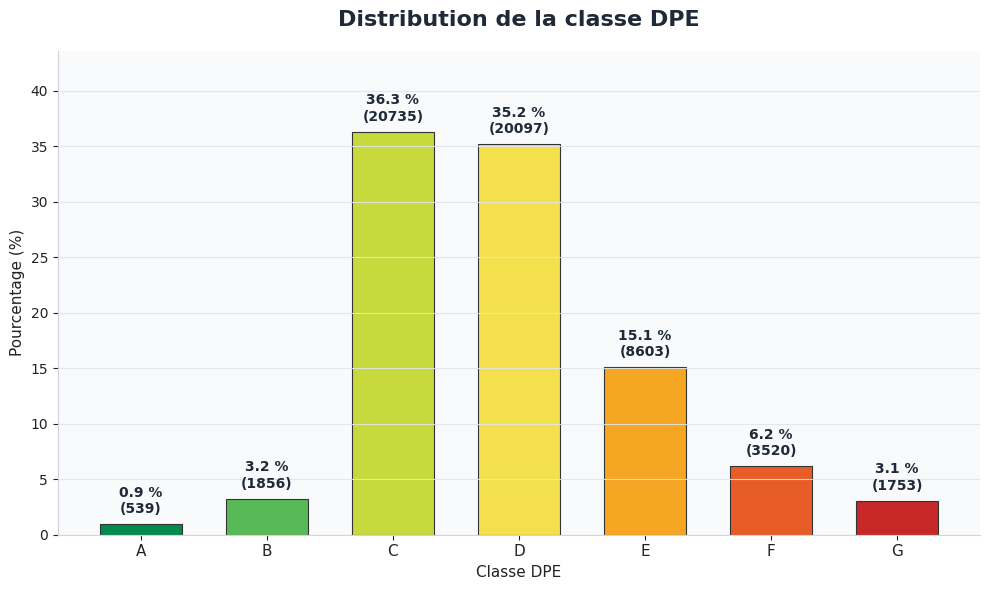

WindowsPath('src/plots/cat/distribution_etiquette_dpe.png')

In [32]:
plot_target_dpe(df, classes_dpe=CLASSES_DPE, dpe_colors=DPE_COLORS, target_col="etiquette_dpe")

# Regroupement de la target

In [33]:
df = creer_target_dpe_3_classes(df)
NEW_TARGET = "classe_dpe_4"
NEW_CLASSES_DPE = ["performant", "intermediaire", "energivore"]

NEW_DPE_COLORS = {
    "performant": "#008A4B",
    "intermediaire": "#F4E04D",
    "energivore": "#C62828",
}

TARGET_ORDER = [
    "performant",
    "intermediaire",
    "energivore",
]

df = df.drop(TARGET)
cat_cols.remove(TARGET)

### Visualisation de la nouvelle target

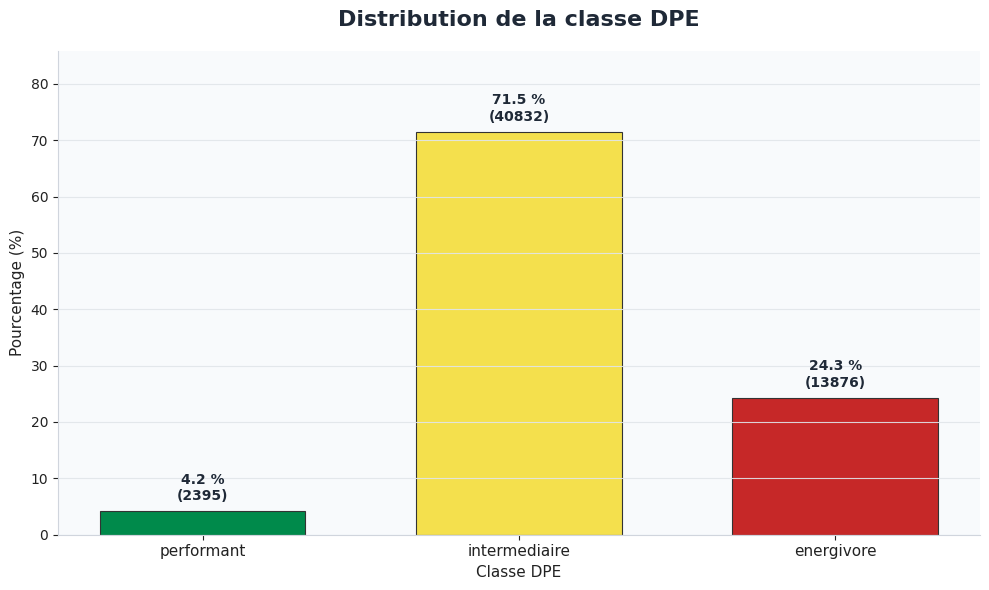

WindowsPath('src/plots/cat/distribution_classe_dpe_4.png')

In [34]:
plot_target_dpe(df, classes_dpe=NEW_CLASSES_DPE, dpe_colors=NEW_DPE_COLORS, target_col=NEW_TARGET)

# Comment regrouper la variable periode_construction ?

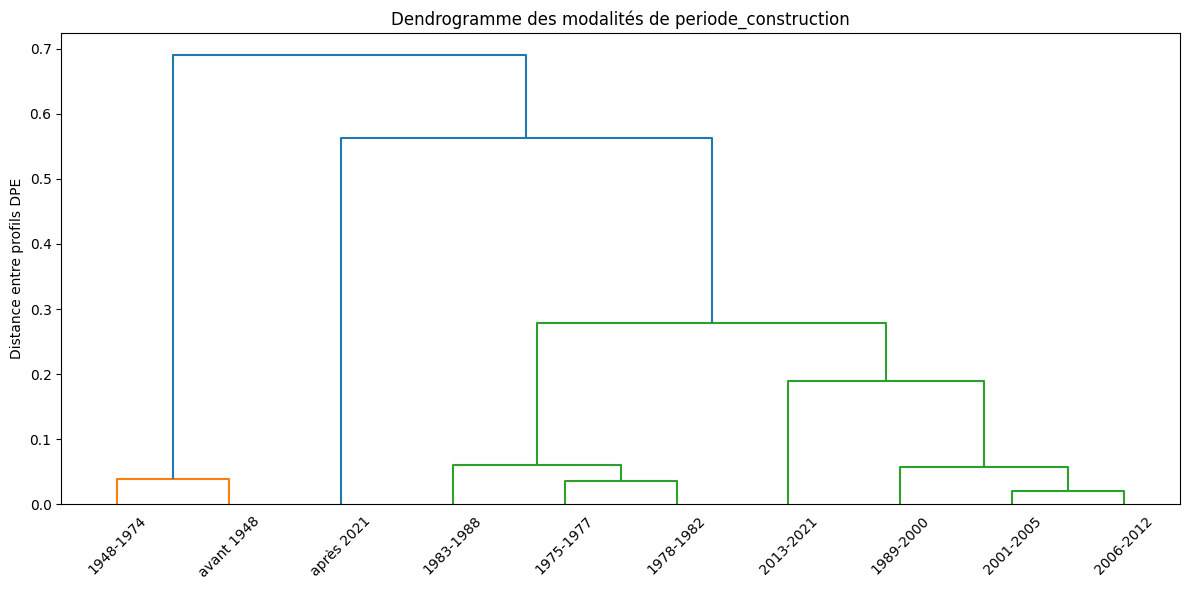

In [35]:
profils_periode, Z_periode = dendrogramme_modalites_vs_target(
    df=df,
    col="periode_construction",
    target=NEW_TARGET,   # adapte si ta cible 3 classes a un autre nom
    min_effectif=100
)

# Préparation de l'analyse bivariée

## Regroupement des variables catégorielles

In [36]:
df = appliquer_regroupements_modalites(
    df=df,
    modalites_groupings=MODALITES_GROUPINGS
)

In [37]:
new_var_to_drop = list(MODALITES_GROUPINGS.keys()) + ["etiquette_dpe", "hauteur_sous_plafond", "numero_etage_appartement"]

var_to_drop = [*var_to_drop, *new_var_to_drop]

num_cols.remove("hauteur_sous_plafond")

In [38]:
colonnes_quali_regroupees = [
    f"{col}_regroupee"
    for col in MODALITES_GROUPINGS.keys()
]

colonnes_quali_regroupees

['zone_climatique_regroupee',
 'type_generateur_n1_installation_n1_regroupee',
 'type_emetteur_installation_chauffage_n1_regroupee',
 'type_generateur_n1_ecs_n1_regroupee',
 'type_energie_principale_chauffage_regroupee',
 'type_energie_principale_ecs_regroupee',
 'configuration_installation_chauffage_n1_regroupee',
 'periode_construction_regroupee']

## Checking des regroupements

In [39]:
controle_regroupements_modalites(
    df=df,
    colonnes_regroupees=colonnes_quali_regroupees
)

colonne,nb_modalites,missing_count,missing_%,autre_count,autre_%
str,i64,i64,f64,i64,f64
"""periode_construction_regroupee""",5,0,0.0,35189,61.62
"""zone_climatique_regroupee""",3,0,0.0,0,0.0
"""type_generateur_n1_installation_n1_regroupee""",14,26,0.05,0,0.0
"""type_emetteur_installation_chauffage_n1_regroupee""",13,26,0.05,0,0.0
"""type_generateur_n1_ecs_n1_regroupee""",16,227,0.4,0,0.0
"""type_energie_principale_chauffage_regroupee""",7,0,0.0,0,0.0
"""type_energie_principale_ecs_regroupee""",8,0,0.0,0,0.0
"""configuration_installation_chauffage_n1_regroupee""",7,26,0.05,0,0.0


## Discrétisation de la variable production_electricite_pv_kwhep_par_an

### Distribution de la variable

In [40]:
resume_production_pv_positive(df)

nb_valeurs_positives,min,q25,mediane,q75,q90,q95,q99,max
u32,f32,f32,f32,f32,f32,f32,f32,f32
582,95.800003,818.099976,2138.600098,4938.299805,7502.600098,9646.099609,14688.0,460380.8125


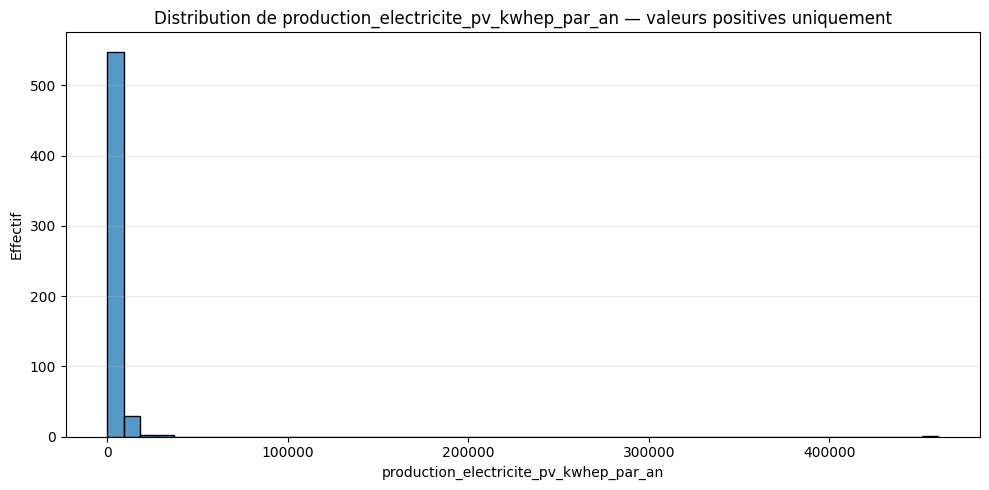

WindowsPath('src/plots/num/distribution_production_electricite_pv_kwhep_par_an_positives.png')

In [41]:
plot_dist(df, col="production_electricite_pv_kwhep_par_an", positive_only=True)

### Distribution sans le max

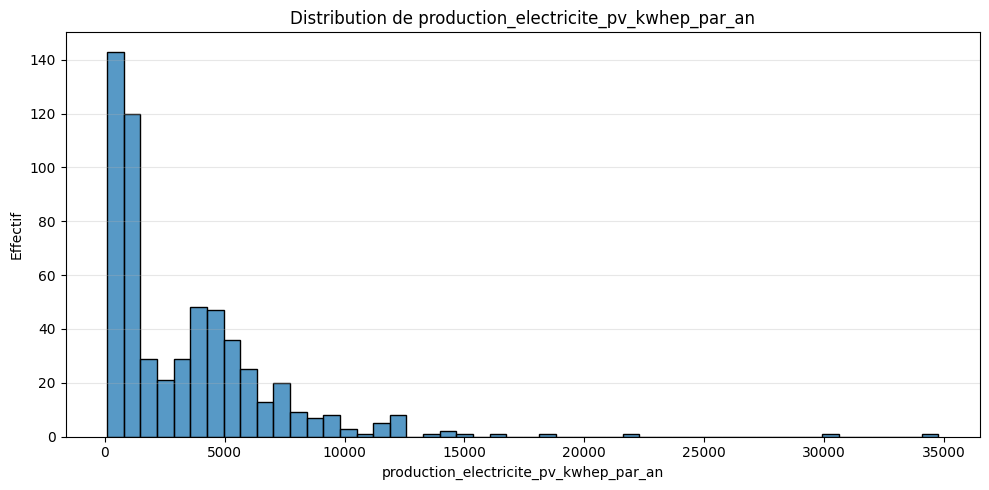

In [42]:
col = "production_electricite_pv_kwhep_par_an"

out_dir = Path("src/plots/num")
filename = f"Dist {col} without max"

fig_path = out_dir / filename

values = df.get_column(col).drop_nulls()

values = values.filter((values > 0) & (values < values.max()))

values = values.to_numpy()

fig, ax = plt.subplots(figsize=(10, 5), facecolor="white")

sns.histplot(
    values,
    bins=50,
    kde=False,
    ax=ax
)

titre = f"Distribution de {col}"

ax.set_title(titre)
ax.set_xlabel(col)
ax.set_ylabel("Effectif")
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()

fig.savefig(
    fig_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    transparent=False,
)

plt.show()


### Discrétidation avec Kmeans

#### Train test split

In [43]:
train_df, test_df = split_train_test_polars(
    df,
    target="classe_dpe_4",
    test_size=0.2,
    random_state=42
)

In [44]:
print("Train :", train_df.shape)
print("Test :", test_df.shape)

Train : (45682, 48)
Test : (11421, 48)


In [45]:
train_df[NEW_TARGET].value_counts(normalize=True)

classe_dpe_4,proportion
str,f64
"""intermediaire""",0.715052
"""performant""",0.041942
"""energivore""",0.243006


In [46]:
test_df[NEW_TARGET].value_counts(normalize=True)

classe_dpe_4,proportion
str,f64
"""intermediaire""",0.715086
"""energivore""",0.242973
"""performant""",0.04194


#### Seuil avec Elbow

In [47]:
k_means = KMeans(random_state=42)

In [48]:
X_pv = (
    train_df
    .filter(pl.col(col) > 0)
    .select(col)
    .to_numpy()
)

X_pv_log = np.log1p(X_pv)

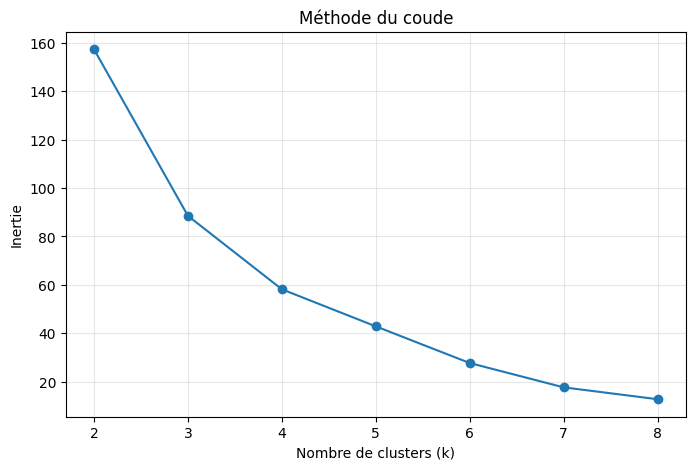

In [49]:
k_range, inertias = elbow_plot(
    X_pv_log,
    k_min=2,
    k_max=8
)

In [50]:
col_pv = "production_pv_kmeans"

In [51]:
kmeans_pv, mapping_pv = fit_kmeans_pv_train(
    train_df,
    col=col,
    n_clusters=3,
    random_state=42
)

# sur le train
train_df = appliquer_kmeans_pv(
    train_df,
    kmeans=kmeans_pv,
    mapping_cluster=mapping_pv,
    col=col
)

# Sur le test
test_df = appliquer_kmeans_pv(
    test_df,
    kmeans=kmeans_pv,
    mapping_cluster=mapping_pv,
    col=col
)

In [52]:
train_df[col_pv].value_counts(normalize=True)

production_pv_kmeans,proportion
str,f64
"""pv_faible""",0.002364
"""aucune_production_pv""",0.989711
"""pv_moyenne""",0.003152
"""pv_elevee""",0.004772


In [53]:
test_df[col_pv].value_counts(normalize=True)

production_pv_kmeans,proportion
str,f64
"""pv_faible""",0.002364
"""pv_moyenne""",0.002452
"""pv_elevee""",0.004991
"""aucune_production_pv""",0.990194


In [54]:
var_to_drop.append("production_electricite_pv_kwhep_par_an")

In [55]:
num_cols.remove("production_electricite_pv_kwhep_par_an")
num_cols

['numero_etage_appartement',
 'volume_stockage_generateur_n1_ecs_n1',
 'hauteur_sous_plafond_corrigee']

# Analyse Bivariée

### Proportion des logements énergivores par départment

In [56]:
taux_energivore_par_modalite(
    df,
    col="code_postal_ban",
    target=NEW_TARGET,
    min_effectif=50,
)

code_postal_ban,effectif_modalite,effectif_energivore,taux_energivore_%
str,u32,u32,f64
"""60270""",122,83,68.03
"""80400""",78,46,58.97
"""2140""",128,75,58.59
"""59570""",106,57,53.77
"""59138""",82,43,52.44
"""2800""",170,88,51.76
"""2300""",192,99,51.56
"""80200""",103,52,50.49
"""59158""",60,29,48.33


### Energie principale utilisée pour le chauffage par type de bâtiment

In [57]:
tableau_quali_quali(
    df,
    "type_batiment",
    "type_energie_principale_chauffage_regroupee"
)

type_batiment,type_energie_principale_chauffage_regroupee,effectif,effectif_col1,pourcentage_dans_col1
str,str,u32,u32,f64
"""appartement""","""Gaz naturel""",13590,27840,48.81
"""appartement""","""Électricité""",10043,27840,36.07
"""appartement""","""Réseau de chaleur""",3981,27840,14.3
"""appartement""","""Fioul domestique""",144,27840,0.52
"""appartement""","""Bois""",57,27840,0.2
"""appartement""","""GPL / Propane / Butane""",25,27840,0.09
"""immeuble""","""Gaz naturel""",863,1681,51.34
"""immeuble""","""Électricité""",659,1681,39.2
"""immeuble""","""Réseau de chaleur""",140,1681,8.33


### Un lien entre les variables numériques

In [58]:
num_cols

['numero_etage_appartement',
 'volume_stockage_generateur_n1_ecs_n1',
 'hauteur_sous_plafond_corrigee']

In [59]:
df[num_cols].drop_nulls().corr()

numero_etage_appartement,volume_stockage_generateur_n1_ecs_n1,hauteur_sous_plafond_corrigee
f64,f64,f64
1.0,-0.037472,-0.021237
-0.037472,1.0,0.044249
-0.021237,0.044249,1.0


### Des hauteurs de sous plafond diffèrent-elles entre les classes énergétiques ?

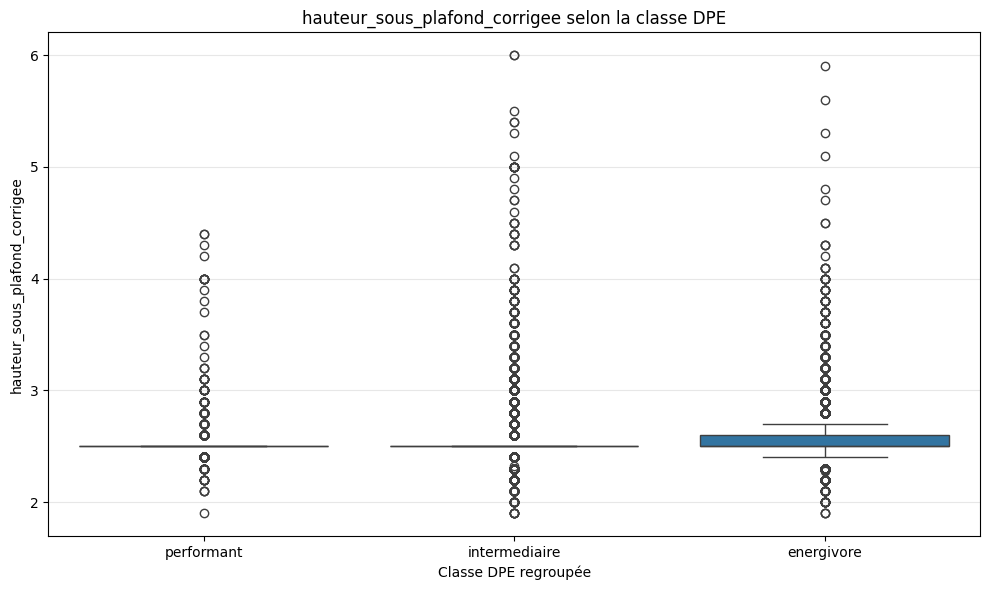

WindowsPath('src/plots/bivariee/boxplot_hauteur_sous_plafond_corrigee_vs_classe_dpe_4.png')

In [60]:
boxplot_vs_target(
    df,
    col="hauteur_sous_plafond_corrigee",
    target=NEW_TARGET,
    target_order=TARGET_ORDER
)

In [61]:
df["hauteur_sous_plafond_corrigee"].value_counts()

hauteur_sous_plafond_corrigee,count
f32,u32
4.5,6
4.2,2
3.0,915
4.4,7
2.5,40686
2.1,91
4.8,2
4.1,6
4.3,8


# Tests Statistiques pour la sélection de variables

In [62]:
var_to_drop.remove(TARGET)
train_df = train_df.drop(var_to_drop)
test_df = test_df.drop(var_to_drop)
df = df.drop(var_to_drop)

cat_cols = list(set(cat_cols) - set(var_to_drop))
num_cols = list(set(num_cols) - set(var_to_drop))

In [63]:
quali_bin_cols, quanti_cols = separer_variables_quali_bin_quanti(
    df=train_df,
    target=TARGET,
    cols_a_exclure=[NEW_TARGET],
)

In [64]:
cat_cols = quali_bin_cols
num_cols = quanti_cols

In [65]:
resultats_tests = tester_variables_avec_target(
    df=train_df,
    target=NEW_TARGET,
    cat_cols=cat_cols,
    numeric_cols=num_cols,
    tester_missing=True,
)

resultats_tests_clean = resultats_tests.filter(
    pl.col("interpretation") != "aucun_missing"
)

resultats_variables = resultats_tests_clean.filter(
    ~pl.col("variable").str.ends_with("_missing")
)

resultats_variables

variable,type_variable,test,n,nb_modalites,statistique,p_value,taille_effet,effet,interpretation,nb_groupes
str,str,str,i64,i64,f64,f64,f64,str,str,i64
"""type_generateur_n1_ecs_n1_regroupee""","""qualitative""","""chi2""",45682,17,17378.4738,0.0,0.4361,"""cramers_v""","""forte""",null
"""type_generateur_n1_installation_n1_regroupee""","""qualitative""","""chi2""",45682,15,14868.7802,0.0,0.4034,"""cramers_v""","""forte""",null
"""qualite_isolation_enveloppe""","""qualitative""","""chi2""",45682,4,10470.545,0.0,0.3385,"""cramers_v""","""forte""",null
"""qualite_isolation_murs""","""qualitative""","""chi2""",45682,5,9573.1133,0.0,0.3237,"""cramers_v""","""forte""",null
"""ventilation_posterieure_2012""","""qualitative""","""chi2""",45682,2,4028.9027,0.0,0.297,"""cramers_v""","""moderee""",null
"""periode_construction_regroupee""","""qualitative""","""chi2""",45682,5,7256.9431,0.0,0.2818,"""cramers_v""","""moderee""",null
"""qualite_isolation_menuiseries""","""qualitative""","""chi2""",45682,4,6065.1664,0.0,0.2577,"""cramers_v""","""moderee""",null
"""type_energie_principale_chauffage_regroupee""","""qualitative""","""chi2""",45682,7,4834.4547,0.0,0.23,"""cramers_v""","""moderee""",null
"""type_energie_principale_ecs_regroupee""","""qualitative""","""chi2""",45682,8,3459.7575,0.0,0.1946,"""cramers_v""","""moderee""",null


In [66]:
features_v1 =  [
    # Générateurs
    "type_generateur_n1_ecs_n1_regroupee",
    "type_generateur_n1_installation_n1_regroupee",

    # Isolation détaillée
    "qualite_isolation_murs",
    "qualite_isolation_menuiseries",
    "qualite_isolation_plancher_bas",

    # Ventilation / bâti
    "ventilation_posterieure_2012",
    "periode_construction_regroupee",
    "type_batiment",

    # Énergies principales
    "type_energie_principale_chauffage_regroupee",
    "type_energie_principale_ecs_regroupee",

    # Émetteur chauffage
    "type_emetteur_installation_chauffage_n1_regroupee",

    # PV
    "has_PV",
]

In [67]:
features_v2 = [
    # Générateurs
    "type_generateur_n1_ecs_n1_regroupee",
    "type_generateur_n1_installation_n1_regroupee",

    # Isolation détaillée
    "qualite_isolation_murs",
    "qualite_isolation_menuiseries",
    "qualite_isolation_plancher_bas",

    # Ventilation / bâti
    "ventilation_posterieure_2012",
    "periode_construction_regroupee",
    "type_batiment",
    "classe_inertie_batiment",

    # Chauffage
    "type_energie_principale_chauffage_regroupee",
    "type_emetteur_installation_chauffage_n1_regroupee",
    "configuration_installation_chauffage_n1_regroupee",
    "usage_generateur_n1_installation_n1",
    "type_installation_chauffage_n1",

    # ECS
    "type_energie_principale_ecs_regroupee",
    "usage_generateur_n1_ecs_n1",
    "type_installation_ecs_n1",
    "configuration_installation_ecs_n1",
    "volume_stockage_generateur_n1_ecs_n1",

    # Solaire / PV
    "has_PV",
    "production_pv_kmeans",
    "type_installation_solaire_n1",

    # Numérique
    "hauteur_sous_plafond_corrigee",

    # Autres
    "classe_altitude",
    "zone_climatique_regroupee",
]

In [68]:
variables_a_supprimer = [
    "numero_etage_appartement_corrige",
    "qualite_isolation_enveloppe",
]

In [69]:
train_df = train_df.drop(variables_a_supprimer)
test_df = test_df.drop(variables_a_supprimer)
df = df.drop(variables_a_supprimer)

cat_cols = list(set(cat_cols) - set(variables_a_supprimer))
num_cols = list(set(num_cols) - set(variables_a_supprimer))

# Preprocessing

In [70]:
X_train = train_df.drop(NEW_TARGET)
y_train = train_df[NEW_TARGET]
X_test = test_df.drop(NEW_TARGET)
y_test = test_df[NEW_TARGET]

## Gestion des valeurs manquantes 

### Visualation des valeurs manquantes par variable

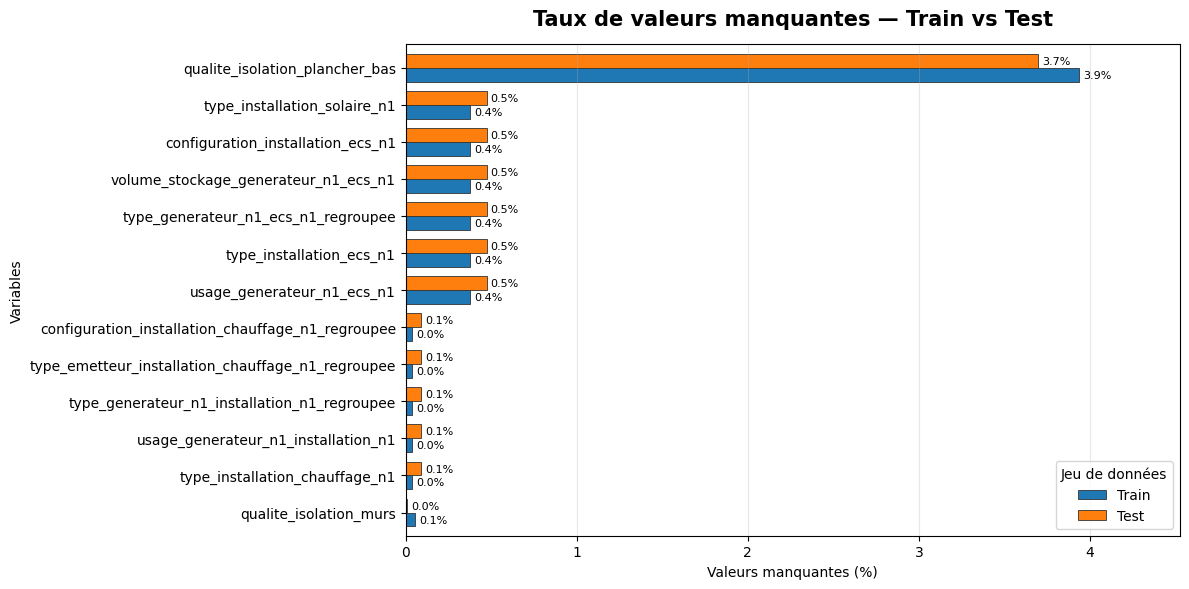

WindowsPath('src/plots/missing/missing_values_train_test.png')

In [71]:
plot_missing_train_test(
    X_train,
    X_test,
    only_missing=True,
    top_n=None,
    verbose=True,
)

### Remplacement des valeurs manquantes

In [72]:
features_v2 = [
    col for col in features_v2
    if col in train_df.columns
]

X_train = train_df.select(features_v2)
y_train = train_df[NEW_TARGET].to_numpy()

X_test = test_df.select(features_v2)
y_test = test_df[NEW_TARGET].to_numpy()

In [73]:
cat_cols_v = [
    col for col in cat_cols
    if col in X_train.columns
]

num_cols_v = [
    col for col in num_cols
    if col in X_train.columns
]

In [74]:
ordinal_cols = [
    "qualite_isolation_murs",
    "qualite_isolation_menuiseries",
    "qualite_isolation_plancher_bas",
    "classe_inertie_batiment",
    "production_pv_kmeans",
]

In [75]:
# Variables nominales = catégorielles moins ordinales
nominal_cols = [
    col for col in cat_cols
    if col not in ordinal_cols
]

# Colonnes numériques avec valeurs manquantes, calculées sur le train uniquement
numeric_cols_missing = colonnes_avec_missing(
    X_train,
    num_cols
)

# Modes des variables ordinales, calculés sur X_train uniquement
ordinal_modes = calculer_modes_train(
    train_df=X_train,
    ordinal_cols=ordinal_cols,
)

# Imputation train
X_train = imputer_apres_selection(
    df=X_train,
    ordinal_cols=ordinal_cols,
    nominal_cols=nominal_cols,
    numeric_cols=num_cols,
    numeric_cols_missing=numeric_cols_missing,
    ordinal_modes=ordinal_modes,
)

# Imputation test avec les mêmes modes
X_test = imputer_apres_selection(
    df=X_test,
    ordinal_cols=ordinal_cols,
    nominal_cols=nominal_cols,
    numeric_cols=num_cols,
    numeric_cols_missing=numeric_cols_missing,
    ordinal_modes=ordinal_modes,
)


In [76]:
# Vérification
cols_miss = X_train.select(cs.ends_with("_missing")).columns

X_train.select(cols_miss).sum()

qualite_isolation_murs_missing,qualite_isolation_menuiseries_missing,qualite_isolation_plancher_bas_missing,classe_inertie_batiment_missing,production_pv_kmeans_missing,volume_stockage_generateur_n1_ecs_n1_missing
i64,i64,i64,i64,i64,i64
25,0,1798,0,0,173


# Pipeline : Encodage + Standardisation

In [77]:
ordre_isolation = [
    "insuffisante",
    "moyenne",
    "bonne",
    "très bonne",
]

ordre_inertie = [
    "Légère",
    "Moyenne",
    "Lourde",
    "Très lourde",
]

ordre_pv = [
    "aucune_production_pv",
    "pv_faible",
    "pv_moyenne",
    "pv_elevee",
]

ordinal_categories = [
    ordre_isolation,  # qualite_isolation_murs
    ordre_isolation,  # qualite_isolation_menuiseries
    ordre_isolation,  # qualite_isolation_plancher_bas
    ordre_inertie,    # classe_inertie_batiment
    ordre_pv,         # production_pv_kmeans
]

## Avec les premières features pertinentes retenues

In [78]:
features_model = X_train.columns

cat_cols, binary_cols, num_cols = separer_colonnes_pipeline(
    X_train,
    features_model
)

cat_cols = list(set(cat_cols) - set(ordinal_cols))

In [79]:
preprocessor = construire_preprocessor(
    ordinal_cols=ordinal_cols,
    nominal_cols=cat_cols,
    numeric_cols=num_cols,
    binary_cols=binary_cols,
    ordinal_categories=ordinal_categories,
)

In [80]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('ordinal', ...), ('ordinal_missing', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``f

In [81]:
X_train_pd = X_train.to_pandas()
X_test_pd = X_test.to_pandas()

# LES MODELES

## BASELINE 

In [82]:
warnings.filterwarnings("ignore")

# Sécurité si les labels ne sont pas exactement ceux-là
labels_train = set(pd.Series(y_train).dropna().unique())

if not set(TARGET_ORDER).issubset(labels_train):
    CLASSES = sorted(pd.Series(y_train).dropna().unique())

print("Classes utilisées :", TARGET_ORDER)

cv5 = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)


def make_model_pipeline(estimator, preprocessor):
    """
    Crée un pipeline complet :
    preprocessing final du projet + modèle.

    clone(preprocessor) évite qu'un même preprocessor déjà fit soit partagé
    entre plusieurs modèles.
    """
    return Pipeline(
        steps=[
            ("preprocessor", clone(preprocessor)),
            ("clf", estimator),
        ]
    )


def compute_sample_weight_multiclass(
    y,
    class_weights: dict | None = None,
):
    """
    Crée des poids d'observation pour les modèles qui n'ont pas class_weight,
    comme AdaBoost ou GradientBoostingClassifier.

    Par défaut, on donne plus de poids aux classes minoritaires via une logique équilibrée.
    """
    y_series = pd.Series(y)

    if class_weights is None:
        counts = y_series.value_counts()
        n = len(y_series)
        k = len(counts)

        class_weights = {
            cls: n / (k * count)
            for cls, count in counts.items()
        }

    return y_series.map(class_weights).to_numpy()


def evaluate_predictions(y_true, y_pred, model_name):
    """
    Retourne les principales métriques utilisées dans le rapport.
    """
    return {
        "Modele": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "F1 macro": f1_score(y_true, y_pred, average="macro"),
        "Precision macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Recall macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
    }


def get_scores_for_curves(model, X, classes):
    """
    Récupère des scores compatibles avec les courbes ROC / Precision-Recall.

    - Si le modèle a predict_proba : on utilise les probabilités.
    - Sinon, si le modèle a decision_function : on utilise les scores de décision.
    """
    clf = model.named_steps["clf"]

    if hasattr(model, "predict_proba"):
        scores_raw = model.predict_proba(X)
        class_order = list(model.classes_)

    elif hasattr(model, "decision_function"):
        scores_raw = model.decision_function(X)
        class_order = list(model.classes_)

    else:
        raise ValueError(
            "Ce modèle ne fournit ni predict_proba ni decision_function."
        )

    # Cas multiclasse : réordonner les colonnes selon CLASSES
    if scores_raw.ndim == 2:
        reorder_idx = [class_order.index(cls) for cls in classes]
        return scores_raw[:, reorder_idx]

    raise ValueError("Format de scores non compatible avec le multiclasse.")


Classes utilisées : ['performant', 'intermediaire', 'energivore']


In [83]:
models_config = {
    # Régression logistique
    "Logistic Ridge": {
        "estimator": LogisticRegression(
            penalty="l2",
            solver="lbfgs",
            C=1.0,
            class_weight="balanced",
            max_iter=3000,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        "use_sample_weight": False,
    },

    "Logistic Lasso": {
        "estimator": LogisticRegression(
            penalty="l1",
            solver="saga",
            C=0.5,
            class_weight="balanced",
            max_iter=3000,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        "use_sample_weight": False,
    },

    "Logistic ElasticNet": {
        "estimator": LogisticRegression(
            penalty="elasticnet",
            solver="saga",
            C=1.0,
            l1_ratio=0.5,
            class_weight="balanced",
            max_iter=3000,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        "use_sample_weight": False,
    },

    # Arbres
    "Decision Tree": {
        "estimator": DecisionTreeClassifier(
            max_depth=15,
            min_samples_leaf=30,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        ),
        "use_sample_weight": False,
    },

    "Random Forest": {
        "estimator": RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            min_samples_leaf=5,
            max_features="sqrt",
            class_weight="balanced_subsample",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        "use_sample_weight": False,
    },

    # Boosting scikit-learn
    "AdaBoost": {
        "estimator": AdaBoostClassifier(
            n_estimators=200,
            learning_rate=0.5,
            random_state=RANDOM_STATE,
        ),
        "use_sample_weight": True,
    },

    "Gradient Boosting": {
        "estimator": GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            random_state=RANDOM_STATE,
        ),
        "use_sample_weight": True,
    },

    # SVM linéaire
    "Linear SVM": {
        "estimator": LinearSVC(
            C=1.0,
            class_weight="balanced",
            max_iter=5000,
            random_state=RANDOM_STATE,
        ),
        "use_sample_weight": False,
    },
}


trained_models = {}
results_rows = {}

sample_weight_train = compute_sample_weight_multiclass(y_train)

for model_name, config in models_config.items():
    print(f"\n===== Entraînement : {model_name} =====")

    model = make_model_pipeline(
        estimator=config["estimator"],
        preprocessor=preprocessor,
    )

    start = time.time()

    if config["use_sample_weight"]:
        model.fit(
            X_train_pd,
            y_train,
            clf__sample_weight=sample_weight_train,
        )
    else:
        model.fit(
            X_train_pd,
            y_train,
        )

    duration = time.time() - start

    y_pred = model.predict(X_test_pd)

    metrics = evaluate_predictions(
        y_true=y_test,
        y_pred=y_pred,
        model_name=model_name,
    )

    metrics["Temps entrainement (s)"] = duration

    trained_models[model_name] = model
    results_rows[model_name] = metrics

    print(
        f"F1 macro = {metrics['F1 macro']:.4f} | "
        f"Balanced accuracy = {metrics['Balanced Accuracy']:.4f} | "
        f"Temps = {duration:.1f}s"
    )


df_results = (
    pd.DataFrame(results_rows.values())
    .sort_values("F1 macro", ascending=False)
    .reset_index(drop=True)
)

display(df_results)

BEST_MODEL_NAME = df_results.loc[0, "Modele"]
best_model = trained_models[BEST_MODEL_NAME]

print(f"\nMeilleur modèle actuel : {BEST_MODEL_NAME}")



===== Entraînement : Logistic Ridge =====
F1 macro = 0.6396 | Balanced accuracy = 0.7863 | Temps = 46.3s

===== Entraînement : Logistic Lasso =====
F1 macro = 0.6445 | Balanced accuracy = 0.8002 | Temps = 685.8s

===== Entraînement : Logistic ElasticNet =====
F1 macro = 0.6370 | Balanced accuracy = 0.7855 | Temps = 744.3s

===== Entraînement : Decision Tree =====
F1 macro = 0.6612 | Balanced accuracy = 0.8209 | Temps = 1.8s

===== Entraînement : Random Forest =====
F1 macro = 0.7094 | Balanced accuracy = 0.8248 | Temps = 10.3s

===== Entraînement : AdaBoost =====
F1 macro = 0.6444 | Balanced accuracy = 0.7624 | Temps = 54.2s

===== Entraînement : Gradient Boosting =====
F1 macro = 0.6668 | Balanced accuracy = 0.8161 | Temps = 225.7s

===== Entraînement : Linear SVM =====
F1 macro = 0.6925 | Balanced accuracy = 0.7527 | Temps = 8.7s


,Modele,Accuracy,Balanced Accuracy,F1 macro,Precision macro,Recall macro,Temps entrainement (s)
0,Random Forest,0.765432,0.824833,0.709399,0.661355,0.824833,10.343981
1,Linear SVM,0.773225,0.752723,0.692460,0.656024,0.752723,8.701443
2,Gradient Boosting,0.731284,0.816101,0.666766,0.622608,0.816101,225.717374
3,Decision Tree,0.730496,0.820895,0.661159,0.617855,0.820895,1.818551
4,Logistic Lasso,0.717538,0.800187,0.644494,0.604440,0.800187,685.839371
5,AdaBoost,0.726206,0.762381,0.644372,0.602526,0.762381,54.218049
6,Logistic Ridge,0.716575,0.786299,0.639594,0.600948,0.786299,46.265306
7,Logistic ElasticNet,0.714824,0.785482,0.637009,0.598959,0.785482,744.283059



Meilleur modèle actuel : Random Forest


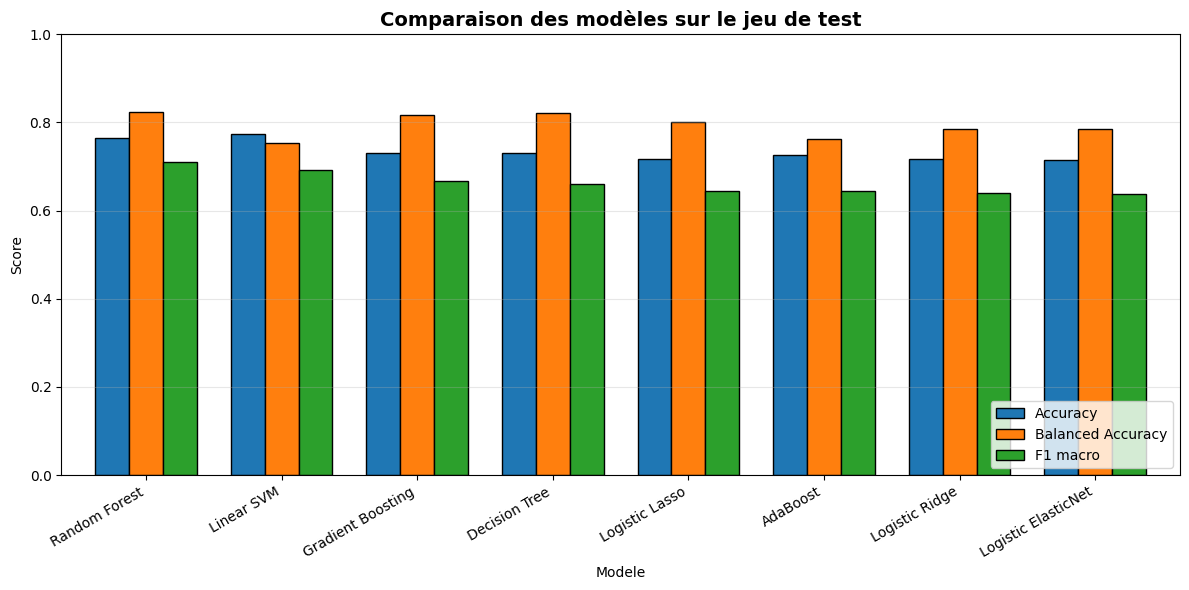

In [84]:
def plot_model_comparison(df_results):
    """
    Compare les modèles sur les métriques principales.
    """
    metrics_to_plot = [
        "Accuracy",
        "Balanced Accuracy",
        "F1 macro",
    ]

    df_plot = df_results.set_index("Modele")[metrics_to_plot]

    ax = df_plot.plot(
        kind="bar",
        figsize=(12, 6),
        width=0.75,
        edgecolor="black",
    )

    ax.set_title("Comparaison des modèles sur le jeu de test", fontsize=14, fontweight="bold")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1)
    ax.grid(axis="y", alpha=0.3)
    ax.legend(loc="lower right")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()


plot_model_comparison(df_results)


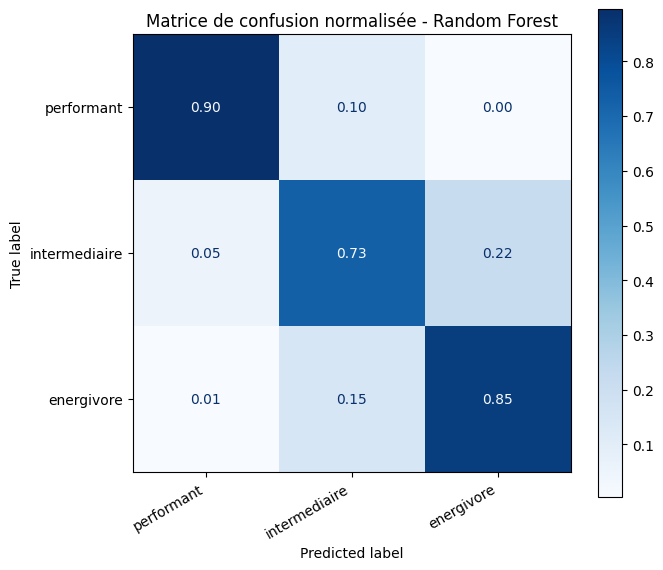

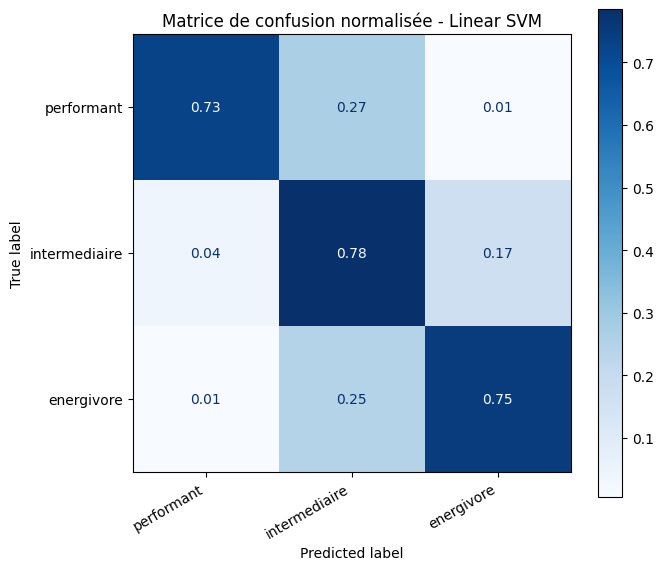

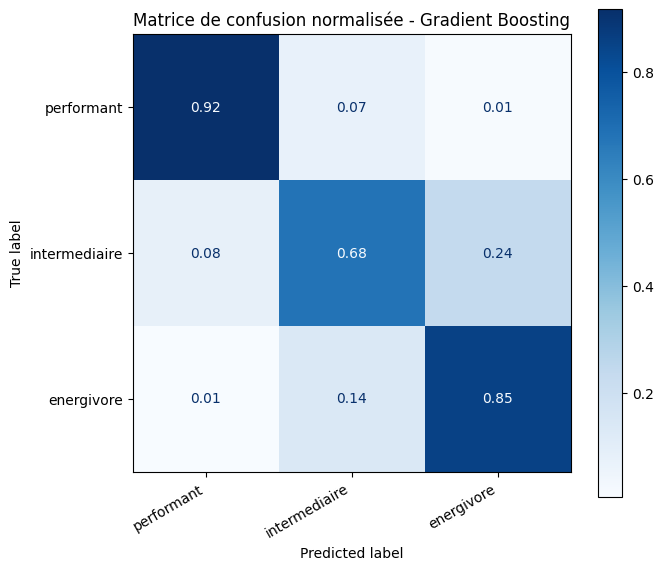

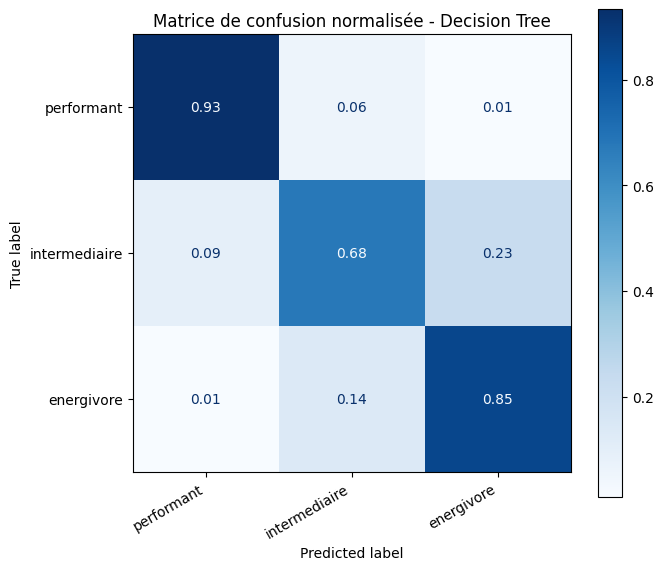

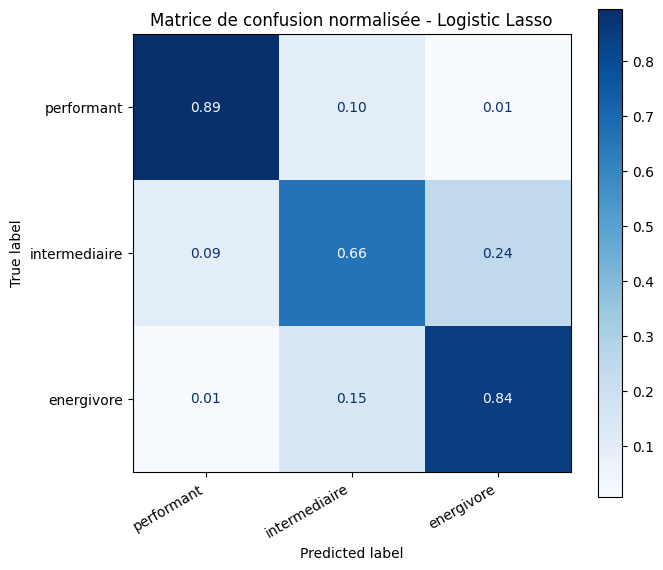

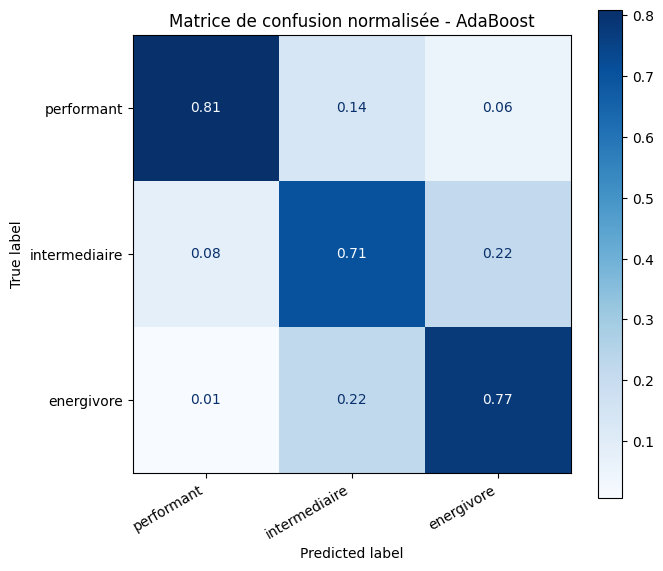

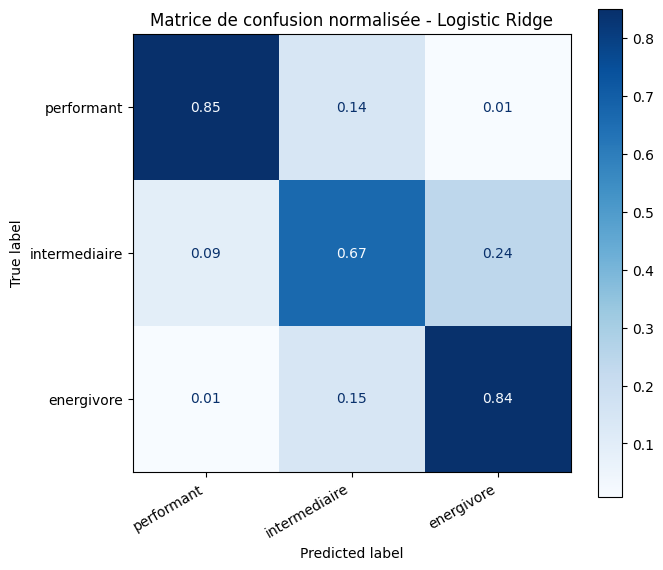

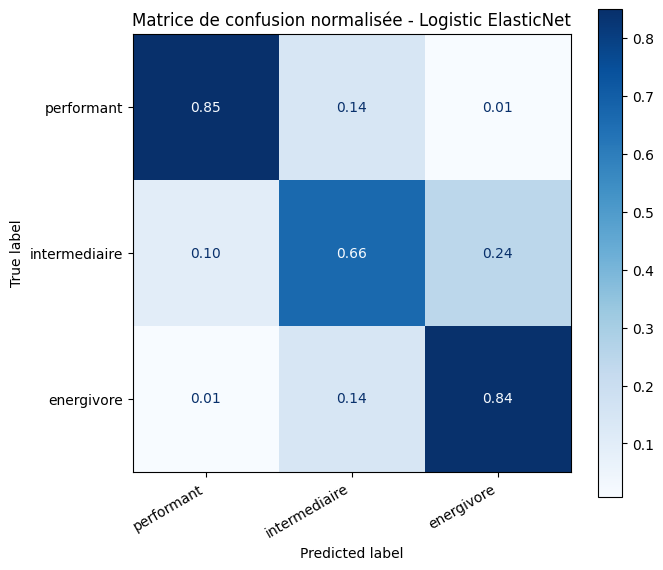

In [85]:
def afficher_matrice_confusion(model_name, trained_models, X_test_pd, y_test, classes):
    model = trained_models[model_name]
    y_pred = model.predict(X_test_pd)

    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=classes,
        normalize="true"
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=classes
    )

    fig, ax = plt.subplots(figsize=(7, 6))
    disp.plot(
        ax=ax,
        cmap="Blues",
        values_format=".2f",
        colorbar=True
    )

    ax.set_title(f"Matrice de confusion normalisée - {model_name}")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()


for model_name in df_results["Modele"]:
    afficher_matrice_confusion(
        model_name=model_name,
        trained_models=trained_models,
        X_test_pd=X_test_pd,
        y_test=y_test,
        classes=TARGET_ORDER,
    )

In [86]:
def rapport_classification_df(model_name, trained_models, X_test_pd, y_test, classes):
    model = trained_models[model_name]
    y_pred = model.predict(X_test_pd)

    report = classification_report(
        y_test,
        y_pred,
        labels=classes,
        output_dict=True,
        zero_division=0
    )

    df_report = pd.DataFrame(report).T
    df_report.insert(0, "Modele", model_name)

    return df_report


reports = {}

for model_name in df_results["Modele"]:
    reports[model_name] = rapport_classification_df(
        model_name=model_name,
        trained_models=trained_models,
        X_test_pd=X_test_pd,
        y_test=y_test,
        classes=TARGET_ORDER,
    )

    print(f"\n===== {model_name} =====")
    display(reports[model_name])


===== Random Forest =====


,Modele,precision,recall,f1-score,support
performant,Random Forest,0.483108,0.895616,0.627652,479.000000
intermediaire,Random Forest,0.929597,0.729154,0.817265,8167.000000
energivore,Random Forest,0.571359,0.849730,0.683280,2775.000000
accuracy,Random Forest,0.765432,0.765432,0.765432,0.765432
macro avg,Random Forest,0.661355,0.824833,0.709399,11421.000000
weighted avg,Random Forest,0.823829,0.765432,0.776758,11421.000000



===== Linear SVM =====


,Modele,precision,recall,f1-score,support
performant,Linear SVM,0.485356,0.726514,0.581940,479.000000
intermediaire,Linear SVM,0.887827,0.784988,0.833247,8167.000000
energivore,Linear SVM,0.594889,0.746667,0.662192,2775.000000
accuracy,Linear SVM,0.773225,0.773225,0.773225,0.773225
macro avg,Linear SVM,0.656024,0.752723,0.692460,11421.000000
weighted avg,Linear SVM,0.799771,0.773225,0.781145,11421.000000



===== Gradient Boosting =====


,Modele,precision,recall,f1-score,support
performant,Gradient Boosting,0.392665,0.916493,0.549781,479.000000
intermediaire,Gradient Boosting,0.928990,0.679197,0.784694,8167.000000
energivore,Gradient Boosting,0.546168,0.852613,0.665822,2775.000000
accuracy,Gradient Boosting,0.731284,0.731284,0.731284,0.731284
macro avg,Gradient Boosting,0.622608,0.816101,0.666766,11421.000000
weighted avg,Gradient Boosting,0.813481,0.731284,0.745959,11421.000000



===== Decision Tree =====


,Modele,precision,recall,f1-score,support
performant,Decision Tree,0.367901,0.933194,0.527745,479.000000
intermediaire,Decision Tree,0.931929,0.677238,0.784428,8167.000000
energivore,Decision Tree,0.553734,0.852252,0.671303,2775.000000
accuracy,Decision Tree,0.730496,0.730496,0.730496,0.730496
macro avg,Decision Tree,0.617855,0.820895,0.661159,11421.000000
weighted avg,Decision Tree,0.816382,0.730496,0.746176,11421.000000



===== Logistic Lasso =====


,Modele,precision,recall,f1-score,support
performant,Logistic Lasso,0.347685,0.893528,0.500585,479.000000
intermediaire,Logistic Lasso,0.923155,0.664871,0.773009,8167.000000
energivore,Logistic Lasso,0.542479,0.842162,0.659890,2775.000000
accuracy,Logistic Lasso,0.717538,0.717538,0.717538,0.717538
macro avg,Logistic Lasso,0.604440,0.800187,0.644494,11421.000000
weighted avg,Logistic Lasso,0.806526,0.717538,0.734098,11421.000000



===== AdaBoost =====


,Modele,precision,recall,f1-score,support
performant,AdaBoost,0.365784,0.807933,0.503578,479.000000
intermediaire,AdaBoost,0.895506,0.705155,0.789012,8167.000000
energivore,AdaBoost,0.546287,0.774054,0.640525,2775.000000
accuracy,AdaBoost,0.726206,0.726206,0.726206,0.726206
macro avg,AdaBoost,0.602526,0.762381,0.644372,11421.000000
weighted avg,AdaBoost,0.788438,0.726206,0.740963,11421.000000



===== Logistic Ridge =====


,Modele,precision,recall,f1-score,support
performant,Logistic Ridge,0.340586,0.849687,0.486260,479.000000
intermediaire,Logistic Ridge,0.920108,0.665605,0.772433,8167.000000
energivore,Logistic Ridge,0.542149,0.843604,0.660087,2775.000000
accuracy,Logistic Ridge,0.716575,0.716575,0.716575,0.716575
macro avg,Logistic Ridge,0.600948,0.786299,0.639594,11421.000000
weighted avg,Logistic Ridge,0.803969,0.716575,0.733134,11421.000000



===== Logistic ElasticNet =====


,Modele,precision,recall,f1-score,support
performant,Logistic ElasticNet,0.334704,0.849687,0.480236,479.000000
intermediaire,Logistic ElasticNet,0.920150,0.663157,0.770796,8167.000000
energivore,Logistic ElasticNet,0.542024,0.843604,0.659994,2775.000000
accuracy,Logistic ElasticNet,0.714824,0.714824,0.714824,0.714824
macro avg,Logistic ElasticNet,0.598959,0.785482,0.637009,11421.000000
weighted avg,Logistic ElasticNet,0.803721,0.714824,0.731688,11421.000000


In [87]:
rows = []

for model_name in df_results["Modele"]:
    model = trained_models[model_name]
    y_pred = model.predict(X_test_pd)

    report = classification_report(
        y_test,
        y_pred,
        labels=TARGET_ORDER,
        output_dict=True,
        zero_division=0
    )

    for classe in TARGET_ORDER:
        rows.append({
            "Modele": model_name,
            "Classe": classe,
            "Precision": report[classe]["precision"],
            "Recall": report[classe]["recall"],
            "F1": report[classe]["f1-score"],
            "Support": report[classe]["support"],
        })

df_reports_classes = pd.DataFrame(rows)

display(
    df_reports_classes
    .sort_values(["Classe", "F1"], ascending=[True, False])
)

,Modele,Classe,Precision,Recall,F1,Support
2,Random Forest,energivore,0.571359,0.849730,0.683280,2775.0
11,Decision Tree,energivore,0.553734,0.852252,0.671303,2775.0
8,Gradient Boosting,energivore,0.546168,0.852613,0.665822,2775.0
5,Linear SVM,energivore,0.594889,0.746667,0.662192,2775.0
20,Logistic Ridge,energivore,0.542149,0.843604,0.660087,2775.0
23,Logistic ElasticNet,energivore,0.542024,0.843604,0.659994,2775.0
14,Logistic Lasso,energivore,0.542479,0.842162,0.659890,2775.0
17,AdaBoost,energivore,0.546287,0.774054,0.640525,2775.0
4,Linear SVM,intermediaire,0.887827,0.784988,0.833247,8167.0
1,Random Forest,intermediaire,0.929597,0.729154,0.817265,8167.0


## OPTIMISATION

In [88]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

CLASSES = ["performant", "intermediaire", "energivore"] # TARGET_ORDER

cv3 = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE,
)

In [89]:
def make_model_pipeline(estimator, preprocessor):
    """
    Pipeline complet : ton preprocessing final + modèle.
    """
    return Pipeline(
        steps=[
            ("preprocessor", clone(preprocessor)),
            ("clf", estimator),
        ]
    )


def make_class_weight(weight_performant, weight_energivore):
    """
    Poids de classes adaptés aux labels de ton projet.
    """
    return {
        "performant": weight_performant,
        "intermediaire": 1.0,
        "energivore": weight_energivore,
    }


def make_sample_weight(y, weight_performant, weight_energivore):
    """
    Pour les modèles qui n'ont pas class_weight, comme AdaBoost ou Gradient Boosting.
    """
    class_weight = make_class_weight(weight_performant, weight_energivore)
    return pd.Series(y).map(class_weight).to_numpy()


def slice_data(X, idx):
    """
    Permet de découper X, que ce soit un DataFrame pandas ou un array numpy.
    """
    if hasattr(X, "iloc"):
        return X.iloc[idx]
    return X[idx]


def cv_f1_macro(
    pipeline,
    X,
    y,
    cv,
    sample_weight=None,
):
    """
    Validation croisée manuelle pour pouvoir gérer proprement sample_weight.
    """
    y_array = np.asarray(y)
    scores = []

    for train_idx, valid_idx in cv.split(X, y_array):
        X_tr = slice_data(X, train_idx)
        X_val = slice_data(X, valid_idx)

        y_tr = y_array[train_idx]
        y_val = y_array[valid_idx]

        model = clone(pipeline)

        if sample_weight is not None:
            sw_tr = sample_weight[train_idx]
            model.fit(X_tr, y_tr, clf__sample_weight=sw_tr)
        else:
            model.fit(X_tr, y_tr)

        y_pred = model.predict(X_val)
        score = f1_score(y_val, y_pred, average="macro")
        scores.append(score)

    return float(np.mean(scores))


def evaluate_model(model_name, model, X_test, y_test):
    y_pred = model.predict(X_test)

    return {
        "Modele": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
        "F1 macro": f1_score(y_test, y_pred, average="macro"),
        "Precision macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "Recall macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
    }


def make_callback(n_trials, model_name):
    def callback(study, trial):
        if (trial.number + 1) % 5 == 0 or (trial.number + 1) == n_trials:
            print(
                f"{model_name} | Trial {trial.number + 1}/{n_trials} "
                f"| Best F1 macro CV = {study.best_value:.4f}"
            )
    return callback

## RIDGE

In [90]:
def objective_logistic_ridge(trial):
    weight_perf = trial.suggest_float("weight_performant", 1.0, 15.0)
    weight_ener = trial.suggest_float("weight_energivore", 1.0, 6.0)

    class_weight = make_class_weight(weight_perf, weight_ener)

    C = trial.suggest_float("C", 1e-3, 50.0, log=True)

    estimator = LogisticRegression(
        penalty="l2",
        solver="lbfgs",
        C=C,
        class_weight=class_weight,
        max_iter=3000,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

    pipeline = make_model_pipeline(estimator, preprocessor)

    return cv_f1_macro(
        pipeline=pipeline,
        X=X_train_pd,
        y=y_train,
        cv=cv3,
    )

## Linear SVM

In [91]:
def objective_linear_svm(trial):
    weight_perf = trial.suggest_float("weight_performant", 1.0, 15.0)
    weight_ener = trial.suggest_float("weight_energivore", 1.0, 6.0)

    class_weight = make_class_weight(weight_perf, weight_ener)

    C = trial.suggest_float("C", 1e-3, 50.0, log=True)

    estimator = LinearSVC(
        C=C,
        class_weight=class_weight,
        max_iter=8000,
        random_state=RANDOM_STATE,
    )

    pipeline = make_model_pipeline(estimator, preprocessor)

    return cv_f1_macro(
        pipeline=pipeline,
        X=X_train_pd,
        y=y_train,
        cv=cv3,
    )

## Decision Tree

In [92]:
def objective_decision_tree(trial):
    weight_perf = trial.suggest_float("weight_performant", 1.0, 15.0)
    weight_ener = trial.suggest_float("weight_energivore", 1.0, 6.0)

    class_weight = make_class_weight(weight_perf, weight_ener)

    estimator = DecisionTreeClassifier(
        max_depth=trial.suggest_int("max_depth", 4, 25),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 10, 150),
        min_samples_split=trial.suggest_int("min_samples_split", 20, 250),
        criterion=trial.suggest_categorical("criterion", ["gini", "entropy"]),
        class_weight=class_weight,
        random_state=RANDOM_STATE,
    )

    pipeline = make_model_pipeline(estimator, preprocessor)

    return cv_f1_macro(
        pipeline=pipeline,
        X=X_train_pd,
        y=y_train,
        cv=cv3,
    )

## Random Forest

In [93]:
def objective_random_forest(trial):
    weight_perf = trial.suggest_float("weight_performant", 1.0, 15.0)
    weight_ener = trial.suggest_float("weight_energivore", 1.0, 6.0)

    class_weight = make_class_weight(weight_perf, weight_ener)

    estimator = RandomForestClassifier(
        n_estimators=trial.suggest_int("n_estimators", 200, 600, step=100),
        max_depth=trial.suggest_categorical("max_depth", [None, 10, 15, 20, 25, 30]),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 30),
        min_samples_split=trial.suggest_int("min_samples_split", 2, 80),
        max_features=trial.suggest_categorical("max_features", ["sqrt", "log2"]),
        class_weight=class_weight,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

    pipeline = make_model_pipeline(estimator, preprocessor)

    return cv_f1_macro(
        pipeline=pipeline,
        X=X_train_pd,
        y=y_train,
        cv=cv3,
    )

## AdaBoost

In [94]:
def objective_adaboost(trial):
    weight_perf = trial.suggest_float("weight_performant", 1.0, 15.0)
    weight_ener = trial.suggest_float("weight_energivore", 1.0, 6.0)

    sample_weight = make_sample_weight(
        y_train,
        weight_performant=weight_perf,
        weight_energivore=weight_ener,
    )

    estimator = AdaBoostClassifier(
        n_estimators=trial.suggest_int("n_estimators", 50, 400, step=50),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 1.5, log=True),
        random_state=RANDOM_STATE,
    )

    pipeline = make_model_pipeline(estimator, preprocessor)

    return cv_f1_macro(
        pipeline=pipeline,
        X=X_train_pd,
        y=y_train,
        cv=cv3,
        sample_weight=sample_weight,
    )

## Gradient Boosting

In [95]:
def objective_gradient_boosting(trial):
    weight_perf = trial.suggest_float("weight_performant", 1.0, 15.0)
    weight_ener = trial.suggest_float("weight_energivore", 1.0, 6.0)

    sample_weight = make_sample_weight(
        y_train,
        weight_performant=weight_perf,
        weight_energivore=weight_ener,
    )

    estimator = GradientBoostingClassifier(
        n_estimators=trial.suggest_int("n_estimators", 100, 350, step=50),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.25, log=True),
        max_depth=trial.suggest_int("max_depth", 2, 5),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 10, 120),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        random_state=RANDOM_STATE,
    )

    pipeline = make_model_pipeline(estimator, preprocessor)

    return cv_f1_macro(
        pipeline=pipeline,
        X=X_train_pd,
        y=y_train,
        cv=cv3,
        sample_weight=sample_weight,
    )

## XGBOOST

In [96]:
try:
    from xgboost import XGBClassifier
except ImportError:
    raise ImportError(
        "XGBoost n'est pas installé. Installe-le avec : pip install xgboost"
    )


# Encodage manuel de la target pour XGBoost
label_to_id = {
    "performant": 0,
    "intermediaire": 1,
    "energivore": 2,
}

id_to_label = {
    0: "performant",
    1: "intermediaire",
    2: "energivore",
}

y_train_xgb = pd.Series(y_train).map(label_to_id).to_numpy()
y_test_xgb = pd.Series(y_test).map(label_to_id).to_numpy()

if np.isnan(y_train_xgb).any() or np.isnan(y_test_xgb).any():
    raise ValueError(
        "Certains labels de y_train ou y_test ne sont pas dans label_to_id."
    )


In [97]:
def objective_xgboost(trial):
    weight_perf = trial.suggest_float("weight_performant", 1.0, 15.0)
    weight_ener = trial.suggest_float("weight_energivore", 1.0, 6.0)

    sample_weight = make_sample_weight(
        y_train,
        weight_performant=weight_perf,
        weight_energivore=weight_ener,
    )

    estimator = XGBClassifier(
        objective="multi:softprob",
        num_class=3,
        eval_metric="mlogloss",

        n_estimators=trial.suggest_int("n_estimators", 100, 500, step=100),
        max_depth=trial.suggest_int("max_depth", 3, 8),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.25, log=True),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),

        min_child_weight=trial.suggest_int("min_child_weight", 1, 10),
        gamma=trial.suggest_float("gamma", 0.0, 5.0),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 20.0, log=True),

        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0,
    )

    pipeline = make_model_pipeline(estimator, preprocessor)

    return cv_f1_macro(
        pipeline=pipeline,
        X=X_train_pd,
        y=y_train_xgb,
        cv=cv3,
        sample_weight=sample_weight,
    )


## LANCEMENT DES OPTIMISATIONS

In [98]:
N_TRIALS_FAST = 50
N_TRIALS_SLOW = 12
N_TRIAL_MEAN = 20

objectives = {
    "Logistic Ridge Optuna": (objective_logistic_ridge, N_TRIALS_FAST),
    "Linear SVM Optuna": (objective_linear_svm, N_TRIALS_FAST),
    "Decision Tree Optuna": (objective_decision_tree, N_TRIALS_FAST),
    "Random Forest Optuna": (objective_random_forest, N_TRIALS_FAST),
    #"AdaBoost Optuna": (objective_adaboost, N_TRIALS_FAST),
    #"Gradient Boosting Optuna": (objective_gradient_boosting, N_TRIALS_FAST),
    "XGBoost Optuna": (objective_xgboost, N_TRIAL_MEAN),
}

studies = {}

for model_name, (objective, n_trials) in objectives.items():
    print(f"\n===== Optimisation : {model_name} =====")

    study = optuna.create_study(
        direction="maximize",
        sampler=TPESampler(seed=RANDOM_STATE),
        study_name=model_name,
    )

    study.optimize(
        objective,
        n_trials=n_trials,
        callbacks=[make_callback(n_trials, model_name)],
    )

    studies[model_name] = study

    print(f"Meilleur F1 macro CV : {study.best_value:.4f}")
    print("Meilleurs paramètres :")
    print(study.best_params)


===== Optimisation : Logistic Ridge Optuna =====
Logistic Ridge Optuna | Trial 5/50 | Best F1 macro CV = 0.6984
Logistic Ridge Optuna | Trial 10/50 | Best F1 macro CV = 0.7219
Logistic Ridge Optuna | Trial 15/50 | Best F1 macro CV = 0.7226
Logistic Ridge Optuna | Trial 20/50 | Best F1 macro CV = 0.7296
Logistic Ridge Optuna | Trial 25/50 | Best F1 macro CV = 0.7354
Logistic Ridge Optuna | Trial 30/50 | Best F1 macro CV = 0.7354
Logistic Ridge Optuna | Trial 35/50 | Best F1 macro CV = 0.7411
Logistic Ridge Optuna | Trial 40/50 | Best F1 macro CV = 0.7411
Logistic Ridge Optuna | Trial 45/50 | Best F1 macro CV = 0.7412
Logistic Ridge Optuna | Trial 50/50 | Best F1 macro CV = 0.7412
Meilleur F1 macro CV : 0.7412
Meilleurs paramètres :
{'weight_performant': 1.8398408486492928, 'weight_energivore': 1.6154605551655254, 'C': 0.8709164733072404}

===== Optimisation : Linear SVM Optuna =====
Linear SVM Optuna | Trial 5/50 | Best F1 macro CV = 0.7118
Linear SVM Optuna | Trial 10/50 | Best F1 mac

## ENTRAINEMENT

## ANALYSE DES MODELES OPTIMISES

In [100]:
def decode_prediction_if_needed(model_name, y_pred, id_to_label=None):
    """
    XGBoost prédit des classes numériques 0, 1, 2.
    Les autres modèles prédisent directement les labels texte.
    """
    if "XGBoost" in model_name and id_to_label is not None:
        return pd.Series(y_pred).map(id_to_label).to_numpy()
    return y_pred


def get_best_weights_from_study(model_name, studies):
    """
    Récupère les poids Optuna du meilleur essai.
    Utile pour refaire des courbes d'apprentissage cohérentes.
    """
    if model_name not in studies:
        return None, None

    params = studies[model_name].best_params

    weight_perf = params.get("weight_performant", None)
    weight_ener = params.get("weight_energivore", None)

    return weight_perf, weight_ener


def needs_sample_weight(model_name):
    """
    Modèles pour lesquels on avait utilisé sample_weight
    au lieu de class_weight.
    """
    return (
        "AdaBoost" in model_name
        or "Gradient Boosting" in model_name
        or "XGBoost" in model_name
    )


def fit_model_with_correct_target(
    model_name,
    model,
    X,
    y,
    studies=None,
):
    """
    Fit compatible avec :
    - modèles sklearn classiques ;
    - modèles avec sample_weight ;
    - XGBoost avec y encodé.
    """
    model_to_fit = clone(model)

    fit_params = {}

    if studies is not None and needs_sample_weight(model_name):
        weight_perf, weight_ener = get_best_weights_from_study(model_name, studies)

        if weight_perf is not None and weight_ener is not None:
            sw = make_sample_weight(
                y,
                weight_performant=weight_perf,
                weight_energivore=weight_ener,
            )
            fit_params["clf__sample_weight"] = sw

    if "XGBoost" in model_name:
        y_fit = pd.Series(y).map(label_to_id).to_numpy()
    else:
        y_fit = y

    model_to_fit.fit(X, y_fit, **fit_params)

    return model_to_fit


### Courbe d’apprentissage

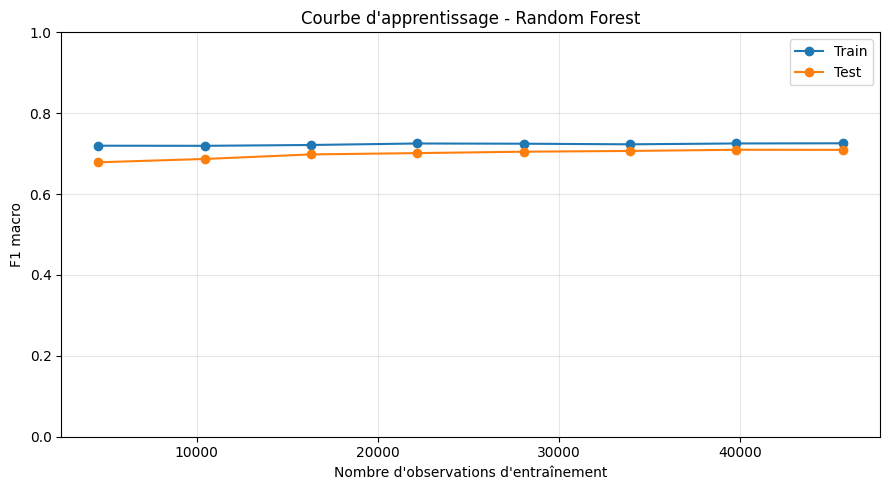

In [101]:
def plot_learning_curve_holdout(
    model_name,
    model,
    X_train_pd,
    X_test_pd,
    y_train,
    y_test,
    train_sizes=np.linspace(0.1, 1.0, 8),
    metric="f1_macro",
    id_to_label=None,
    random_state=42,
):
    """
    Courbe d'apprentissage simple :
    - on entraîne le modèle sur des fractions croissantes du train ;
    - on mesure le score sur la fraction d'entraînement et sur le test fixe.

    Cela permet de visualiser le surapprentissage.
    """

    train_scores = []
    test_scores = []
    sizes_absolute = []

    y_train_series = pd.Series(y_train)

    for frac in train_sizes:
        if frac < 1.0:
            X_sub, _, y_sub, _ = train_test_split(
                X_train_pd,
                y_train_series,
                train_size=frac,
                stratify=y_train_series,
                random_state=random_state,
            )
        else:
            X_sub = X_train_pd
            y_sub = y_train_series

        model_sub = clone(model)

        # Cas XGBoost : il faut entraîner avec y encodé
        if "XGBoost" in model_name and "label_to_id" in globals():
            y_sub_fit = pd.Series(y_sub).map(label_to_id).to_numpy()
            model_sub.fit(X_sub, y_sub_fit)
        else:
            model_sub.fit(X_sub, y_sub)

        y_pred_train = model_sub.predict(X_sub)
        y_pred_test = model_sub.predict(X_test_pd)

        y_pred_train = decode_prediction_if_needed(model_name, y_pred_train, id_to_label)
        y_pred_test = decode_prediction_if_needed(model_name, y_pred_test, id_to_label)

        if metric == "f1_macro":
            score_train = f1_score(y_sub, y_pred_train, average="macro")
            score_test = f1_score(y_test, y_pred_test, average="macro")
            ylabel = "F1 macro"

        elif metric == "balanced_accuracy":
            score_train = balanced_accuracy_score(y_sub, y_pred_train)
            score_test = balanced_accuracy_score(y_test, y_pred_test)
            ylabel = "Balanced accuracy"

        else:
            raise ValueError("metric doit être 'f1_macro' ou 'balanced_accuracy'.")

        train_scores.append(score_train)
        test_scores.append(score_test)
        sizes_absolute.append(len(X_sub))

    plt.figure(figsize=(9, 5))
    plt.plot(sizes_absolute, train_scores, marker="o", label="Train")
    plt.plot(sizes_absolute, test_scores, marker="o", label="Test")
    plt.title(f"Courbe d'apprentissage - {model_name}")
    plt.xlabel("Nombre d'observations d'entraînement")
    plt.ylabel(ylabel)
    plt.ylim(0, 1)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


# Exemple sur le Random Forest
plot_learning_curve_holdout(
    model_name="Random Forest",
    model=trained_models["Random Forest"],
    X_train_pd=X_train_pd,
    X_test_pd=X_test_pd,
    y_train=y_train,
    y_test=y_test,
    metric="f1_macro",
    id_to_label=globals().get("id_to_label", None),
)



In [99]:
def entrainer_modele_optimise(model_name, study):
    params = study.best_params.copy()

    weight_perf = params.pop("weight_performant")
    weight_ener = params.pop("weight_energivore")

    class_weight = make_class_weight(weight_perf, weight_ener)
    sample_weight = make_sample_weight(y_train, weight_perf, weight_ener)

    if model_name == "Logistic Ridge Optuna":
        estimator = LogisticRegression(
            penalty="l2",
            solver="lbfgs",
            **params,
            class_weight=class_weight,
            max_iter=3000,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        use_sample_weight = False

    elif model_name == "Linear SVM Optuna":
        estimator = LinearSVC(
            **params,
            class_weight=class_weight,
            max_iter=8000,
            random_state=RANDOM_STATE,
        )
        use_sample_weight = False

    elif model_name == "Decision Tree Optuna":
        estimator = DecisionTreeClassifier(
            **params,
            class_weight=class_weight,
            random_state=RANDOM_STATE,
        )
        use_sample_weight = False

    elif model_name == "Random Forest Optuna":
        estimator = RandomForestClassifier(
            **params,
            class_weight=class_weight,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        use_sample_weight = False

    elif model_name == "AdaBoost Optuna":
        estimator = AdaBoostClassifier(
            **params,
            random_state=RANDOM_STATE,
        )
        use_sample_weight = True

    elif model_name == "Gradient Boosting Optuna":
        estimator = GradientBoostingClassifier(
            **params,
            random_state=RANDOM_STATE,
        )
        use_sample_weight = True

    elif model_name == "XGBoost Optuna":
        estimator = XGBClassifier(
            objective="multi:softprob",
            num_class=3,
            eval_metric="mlogloss",
            **params,
            tree_method="hist",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=0,
        )
        use_sample_weight = True
        y_fit = y_train_xgb

    else:
        raise ValueError(f"Modèle inconnu : {model_name}")

    pipeline = make_model_pipeline(estimator, preprocessor)

    t0 = time.time()

    if model_name == "XGBoost Optuna":
        if use_sample_weight:
            pipeline.fit(X_train_pd, y_train_xgb, clf__sample_weight=sample_weight)
        else:
            pipeline.fit(X_train_pd, y_train_xgb)
    else:
        if use_sample_weight:
            pipeline.fit(X_train_pd, y_train, clf__sample_weight=sample_weight)
        else:
            pipeline.fit(X_train_pd, y_train)

    duration = time.time() - t0

    return pipeline, duration, class_weight, params


def evaluate_xgboost_model(model_name, model, X_test, y_test):
    y_pred_encoded = model.predict(X_test)
    y_pred = pd.Series(y_pred_encoded).map(id_to_label).to_numpy()

    return {
        "Modele": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
        "F1 macro": f1_score(y_test, y_pred, average="macro"),
        "Precision macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "Recall macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
    }

trained_models_optuna = {}
optuna_summary = []

for model_name, study in studies.items():
    print(f"\n===== Entraînement final : {model_name} =====")

    model, duration, class_weight, best_params = entrainer_modele_optimise(
        model_name=model_name,
        study=study,
    )

    trained_models_optuna[model_name] = model

    if model_name == "XGBoost Optuna":
        metrics = evaluate_xgboost_model(
            model_name=model_name,
            model=model,
            X_test=X_test_pd,
            y_test=y_test,
        )
    else:
        metrics = evaluate_model(
            model_name=model_name,
            model=model,
            X_test=X_test_pd,
            y_test=y_test,
        )

    metrics["F1 macro CV Optuna"] = study.best_value
    metrics["Temps entrainement final (s)"] = duration
    metrics["class_weight"] = class_weight
    metrics["best_params"] = best_params

    optuna_summary.append(metrics)

    print(f"F1 macro test : {metrics['F1 macro']:.4f}")
    print(f"Balanced accuracy test : {metrics['Balanced Accuracy']:.4f}")
    print(f"Temps final : {duration:.1f}s")
    print("Poids :", class_weight)
    print("Paramètres :", best_params)


df_results_optuna = (
    pd.DataFrame(optuna_summary)
    .sort_values("F1 macro", ascending=False)
    .reset_index(drop=True)
)

display(df_results_optuna)


===== Entraînement final : Logistic Ridge Optuna =====
F1 macro test : 0.7323
Balanced accuracy test : 0.7403
Temps final : 21.4s
Poids : {'performant': 1.8398408486492928, 'intermediaire': 1.0, 'energivore': 1.6154605551655254}
Paramètres : {'C': 0.8709164733072404}

===== Entraînement final : Linear SVM Optuna =====
F1 macro test : 0.7062
Balanced accuracy test : 0.7264
Temps final : 8.4s
Poids : {'performant': 6.813480940870612, 'intermediaire': 1.0, 'energivore': 2.51723150444279}
Paramètres : {'C': 11.567216463298225}

===== Entraînement final : Decision Tree Optuna =====
F1 macro test : 0.7426
Balanced accuracy test : 0.7832
Temps final : 1.9s
Poids : {'performant': 1.999242320927121, 'intermediaire': 1.0, 'energivore': 2.561429403930797}
Paramètres : {'max_depth': 25, 'min_samples_leaf': 16, 'min_samples_split': 27, 'criterion': 'gini'}

===== Entraînement final : Random Forest Optuna =====
F1 macro test : 0.7644
Balanced accuracy test : 0.7990
Temps final : 8.6s
Poids : {'perf

,Modele,Accuracy,Balanced Accuracy,F1 macro,Precision macro,Recall macro,F1 macro CV Optuna,Temps entrainement final (s),class_weight,best_params
0,XGBoost Optuna,0.805884,0.799974,0.766224,0.743502,0.799974,0.769535,7.061301,"{'performant': 2.5841212022511684, 'intermedia...","{'n_estimators': 200, 'max_depth': 7, 'learnin..."
1,Random Forest Optuna,0.807635,0.799025,0.764413,0.740242,0.799025,0.767013,8.611180,"{'performant': 3.4528047291300106, 'intermedia...","{'n_estimators': 300, 'max_depth': None, 'min_..."
2,Decision Tree Optuna,0.785483,0.783173,0.742568,0.720630,0.783173,0.730529,1.895704,"{'performant': 1.999242320927121, 'intermediai...","{'max_depth': 25, 'min_samples_leaf': 16, 'min..."
3,Logistic Ridge Optuna,0.794589,0.740298,0.732328,0.727705,0.740298,0.741205,21.373141,"{'performant': 1.8398408486492928, 'intermedia...",{'C': 0.8709164733072404}
4,Linear SVM Optuna,0.784958,0.726361,0.706184,0.690344,0.726361,0.719340,8.426872,"{'performant': 6.813480940870612, 'intermediai...",{'C': 11.567216463298225}


### Courbes ROC-AUC et Precision-Recall

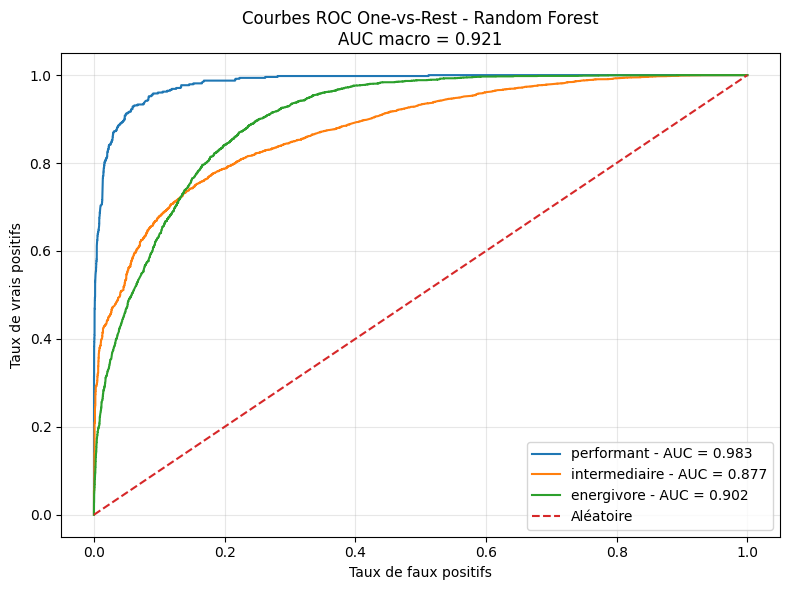

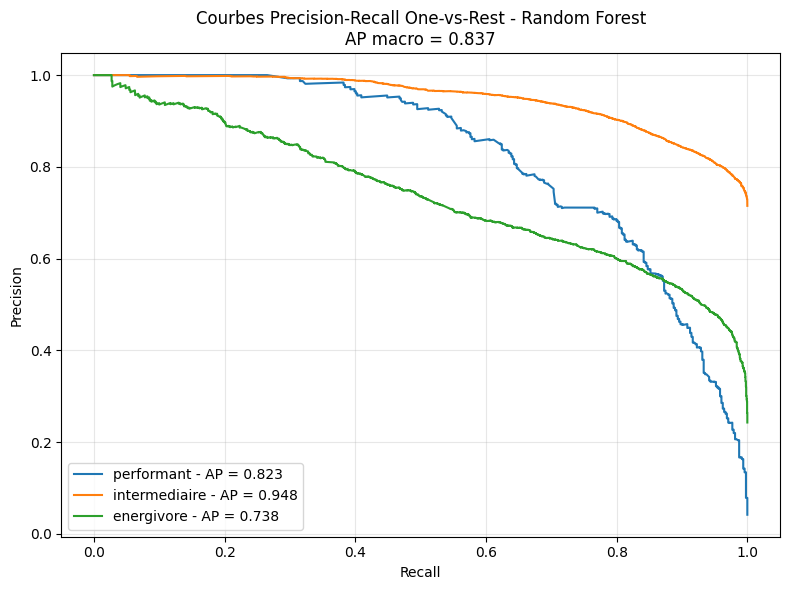

In [102]:
def get_scores_for_auc(model_name, model, X, classes, id_to_label=None):
    """
    Récupère les scores pour ROC-AUC / PR-AUC.
    Fonctionne avec :
    - predict_proba
    - decision_function
    - XGBoost avec classes numériques 0, 1, 2
    """

    clf = model.named_steps["clf"]

    if hasattr(model, "predict_proba"):
        scores = model.predict_proba(X)
        model_classes = list(clf.classes_)

    elif hasattr(model, "decision_function"):
        scores = model.decision_function(X)
        model_classes = list(clf.classes_)

    else:
        raise ValueError(
            f"{model_name} ne fournit ni predict_proba ni decision_function."
        )

    # Cas XGBoost : classes numériques à convertir en labels
    if "XGBoost" in model_name and id_to_label is not None:
        model_classes = [id_to_label[int(c)] for c in model_classes]

    # Réordonner les colonnes selon CLASSES
    reorder_idx = [model_classes.index(cls) for cls in classes]
    scores = scores[:, reorder_idx]

    return scores


def plot_roc_multiclass(
    model_name,
    model,
    X_test_pd,
    y_test,
    classes,
    id_to_label=None,
):
    y_bin = label_binarize(y_test, classes=classes)

    scores = get_scores_for_auc(
        model_name=model_name,
        model=model,
        X=X_test_pd,
        classes=classes,
        id_to_label=id_to_label,
    )

    macro_auc = roc_auc_score(
        y_bin,
        scores,
        average="macro",
        multi_class="ovr",
    )

    plt.figure(figsize=(8, 6))

    for i, cls in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_bin[:, i], scores[:, i])
        roc_auc = auc(fpr, tpr)

        plt.plot(
            fpr,
            tpr,
            label=f"{cls} - AUC = {roc_auc:.3f}"
        )

    plt.plot([0, 1], [0, 1], linestyle="--", label="Aléatoire")
    plt.title(f"Courbes ROC One-vs-Rest - {model_name}\nAUC macro = {macro_auc:.3f}")
    plt.xlabel("Taux de faux positifs")
    plt.ylabel("Taux de vrais positifs")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_precision_recall_multiclass(
    model_name,
    model,
    X_test_pd,
    y_test,
    classes,
    id_to_label=None,
):
    y_bin = label_binarize(y_test, classes=classes)

    scores = get_scores_for_auc(
        model_name=model_name,
        model=model,
        X=X_test_pd,
        classes=classes,
        id_to_label=id_to_label,
    )

    ap_macro = average_precision_score(
        y_bin,
        scores,
        average="macro",
    )

    plt.figure(figsize=(8, 6))

    for i, cls in enumerate(classes):
        precision, recall, _ = precision_recall_curve(y_bin[:, i], scores[:, i])
        ap = average_precision_score(y_bin[:, i], scores[:, i])

        plt.plot(
            recall,
            precision,
            label=f"{cls} - AP = {ap:.3f}"
        )

    plt.title(
        f"Courbes Precision-Recall One-vs-Rest - {model_name}\nAP macro = {ap_macro:.3f}"
    )
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


# Exemple sur Random Forest
plot_roc_multiclass(
    model_name="Random Forest",
    model=trained_models["Random Forest"],
    X_test_pd=X_test_pd,
    y_test=y_test,
    classes=CLASSES,
    id_to_label=globals().get("id_to_label", None),
)

plot_precision_recall_multiclass(
    model_name="Random Forest",
    model=trained_models["Random Forest"],
    X_test_pd=X_test_pd,
    y_test=y_test,
    classes=CLASSES,
    id_to_label=globals().get("id_to_label", None),
)


In [108]:
modeles_a_analyser = [
    "Random Forest Optuna",
    "Linear SVM Optuna",
    #"Gradient Boosting",
    "Decision Tree Optuna",
    #"AdaBoost Optuna",
    "XGBoost Optuna",
    "Logistic Ridge Optuna"

]

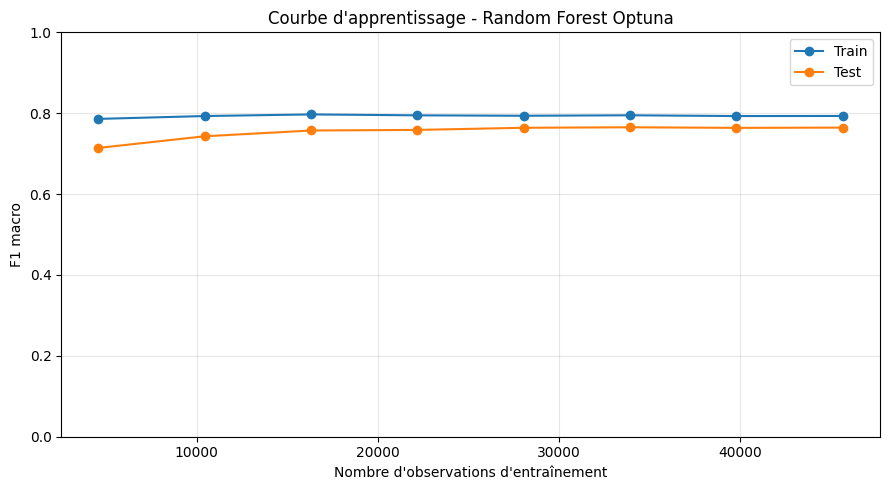

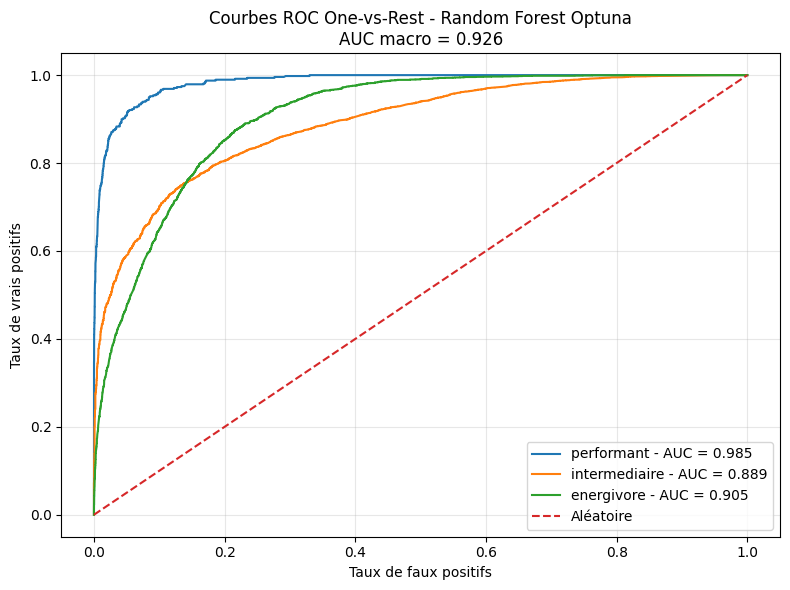

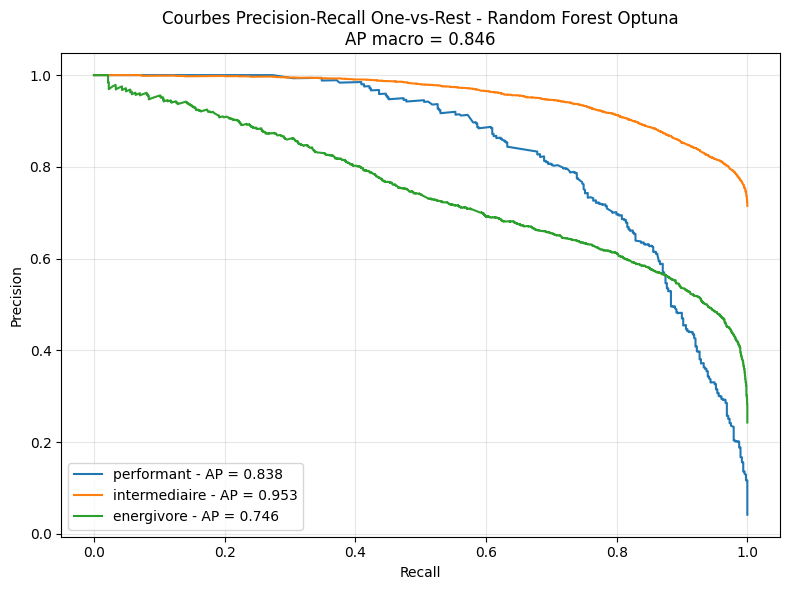

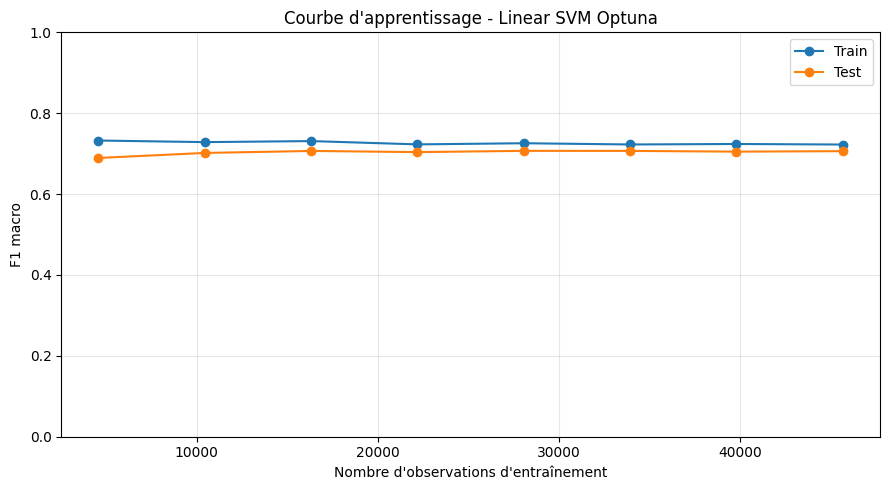

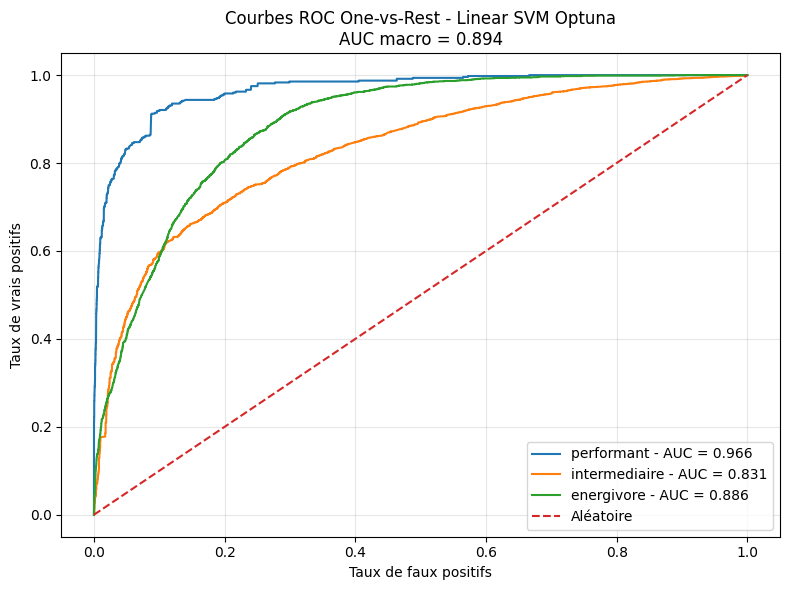

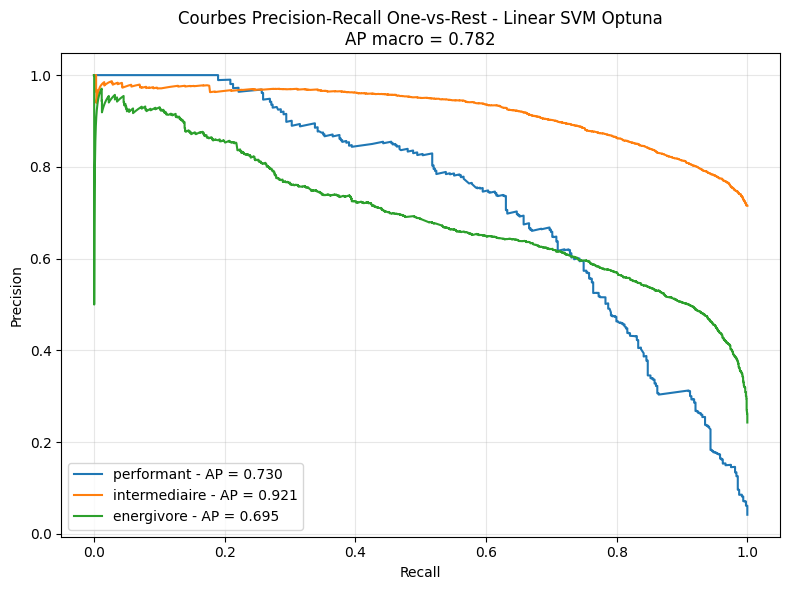

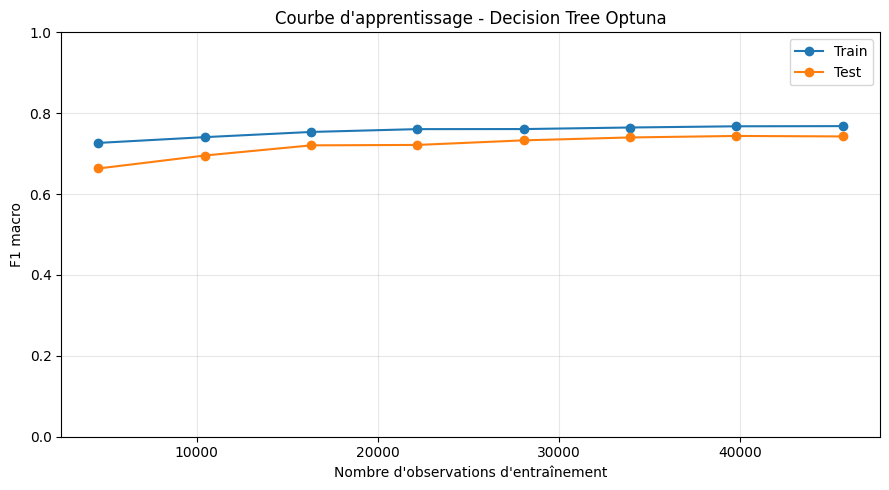

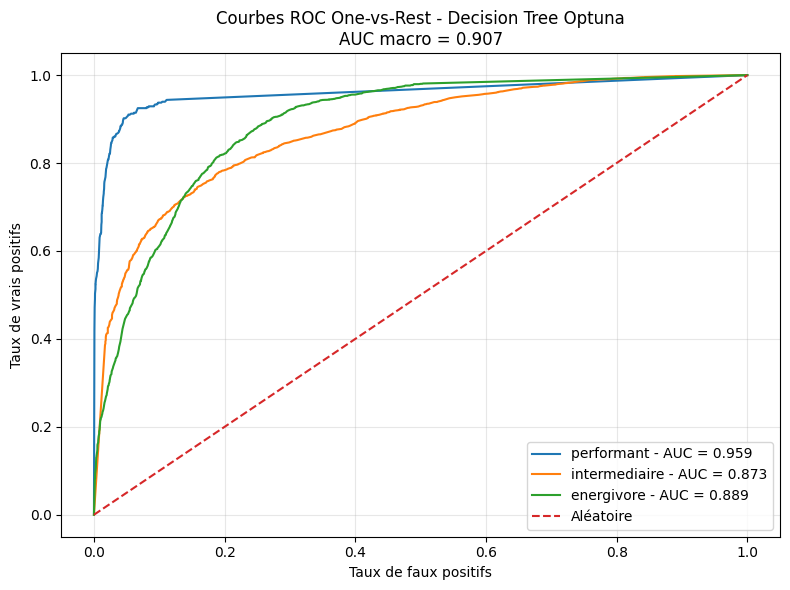

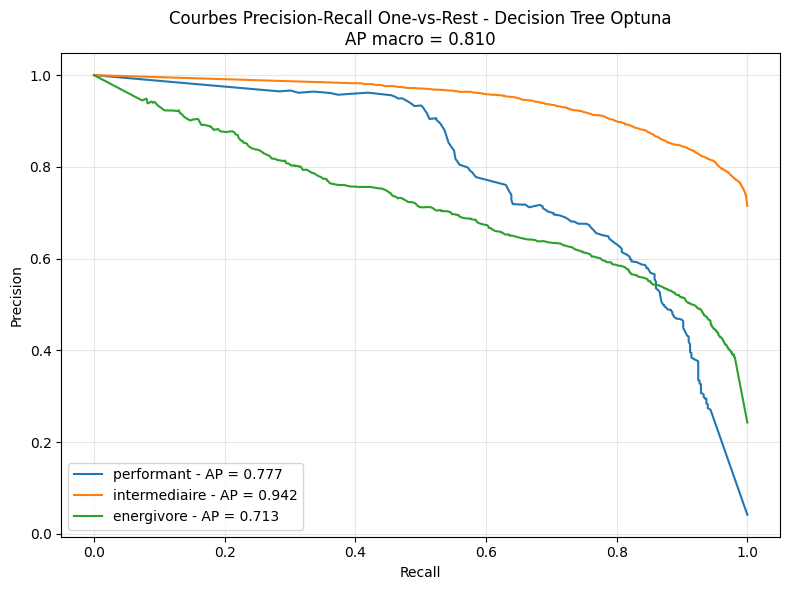

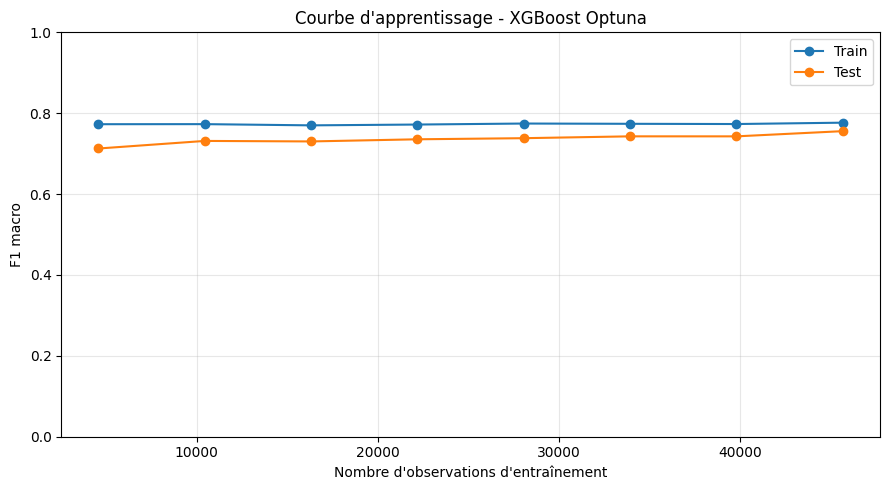

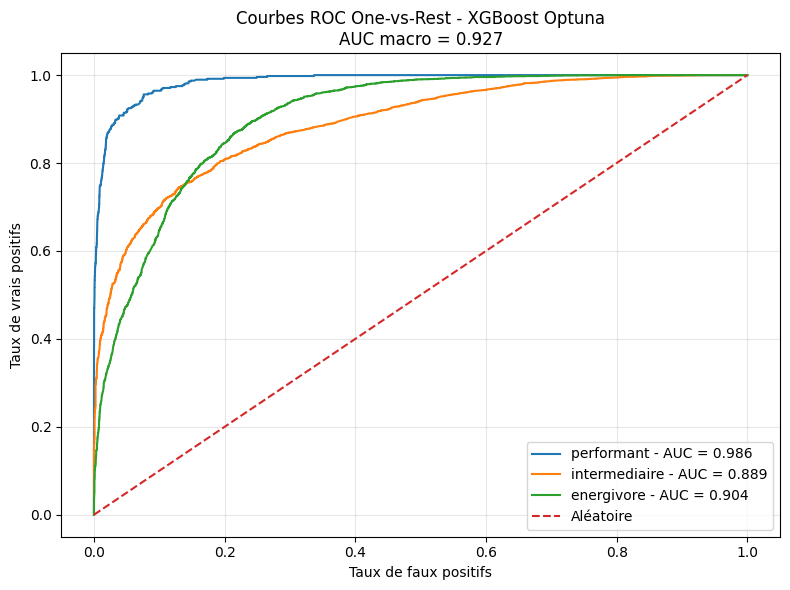

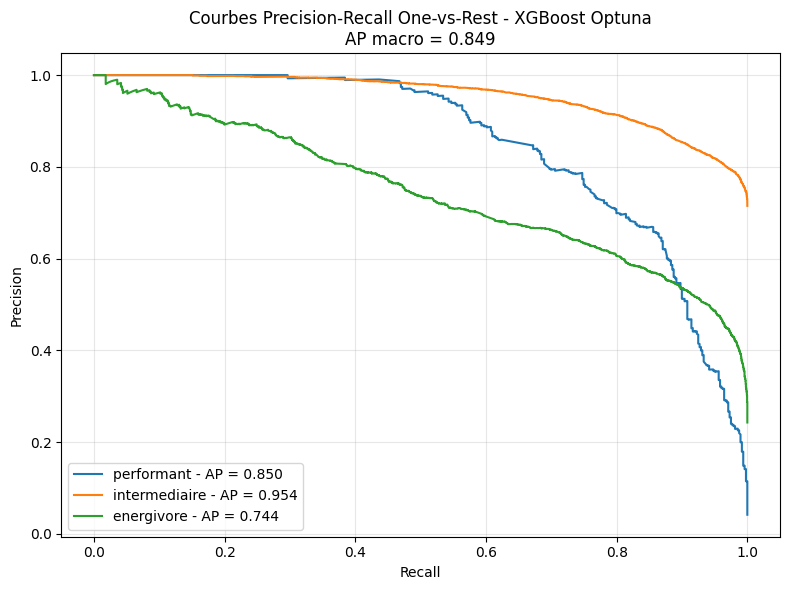

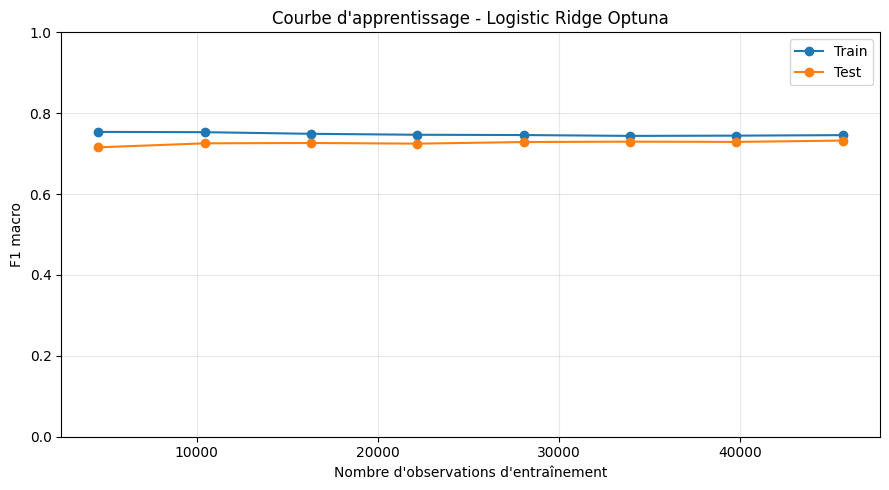

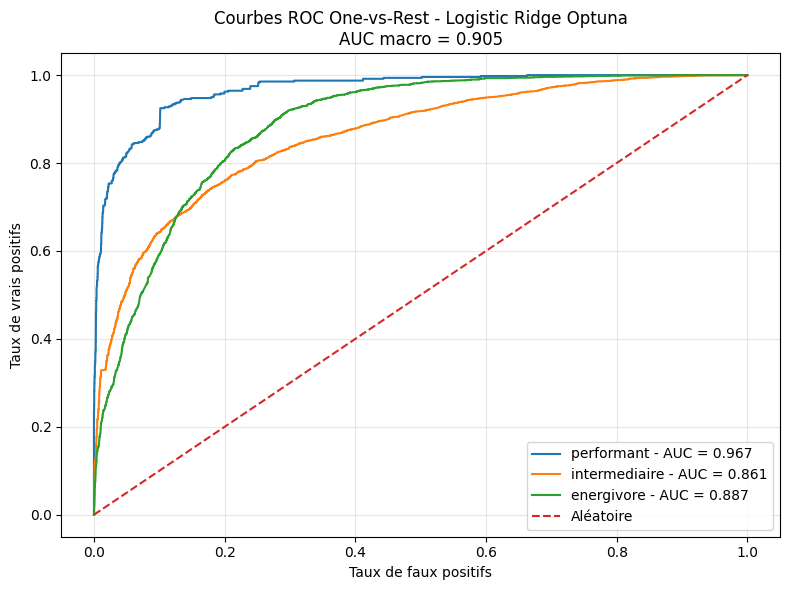

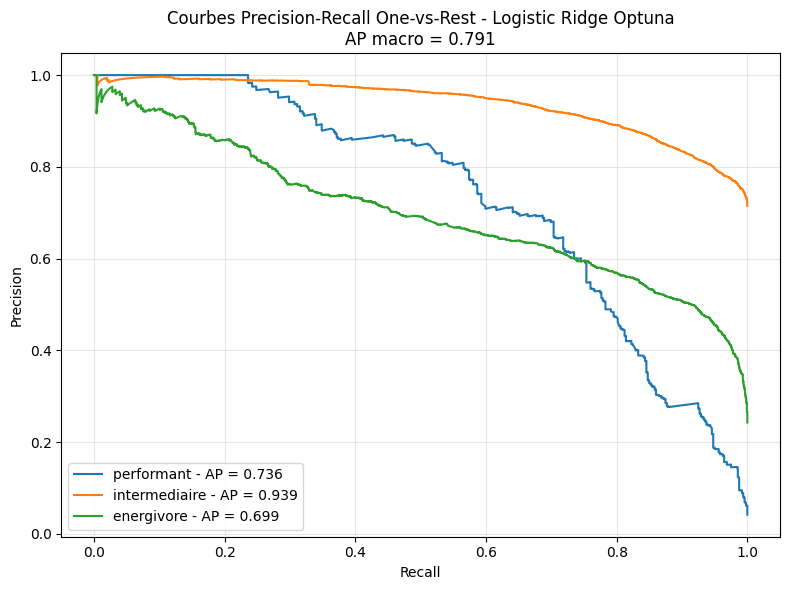

In [109]:
for model_name in modeles_a_analyser:
    plot_learning_curve_holdout(
        model_name=model_name,
        model=trained_models_optuna[model_name],
        X_train_pd=X_train_pd,
        X_test_pd=X_test_pd,
        y_train=y_train,
        y_test=y_test,
        metric="f1_macro",
        id_to_label=globals().get("id_to_label", None),
    )

    plot_roc_multiclass(
        model_name=model_name,
        model=trained_models_optuna[model_name],
        X_test_pd=X_test_pd,
        y_test=y_test,
        classes=CLASSES,
        id_to_label=globals().get("id_to_label", None),
    )

    plot_precision_recall_multiclass(
        model_name=model_name,
        model=trained_models_optuna[model_name],
        X_test_pd=X_test_pd,
        y_test=y_test,
        classes=CLASSES,
        id_to_label=globals().get("id_to_label", None),
    )

## RAPPORT APRES OPTIMISATION

In [111]:
def decoder_predictions(model_name, y_pred, id_to_label):
    """
    Décode les prédictions numériques de XGBoost en labels texte.
    Les autres modèles sklearn prédisent déjà les labels texte.
    """

    if "XGBoost" in model_name:
        return pd.Series(y_pred).map(id_to_label).to_numpy()

    return y_pred


reports_optuna = {}

for model_name, model in trained_models_optuna.items():
    y_pred = model.predict(X_test_pd)

    # Correction spécifique pour XGBoost
    y_pred = decoder_predictions(
        model_name=model_name,
        y_pred=y_pred,
        id_to_label=id_to_label,
    )

    print(f"\n===== Rapport de classification : {model_name} =====")
    print(
        classification_report(
            y_test,
            y_pred,
            labels=CLASSES,
            digits=3,
            zero_division=0,
        )
    )

    reports_optuna[model_name] = classification_report(
        y_test,
        y_pred,
        labels=CLASSES,
        output_dict=True,
        zero_division=0,
    )



===== Rapport de classification : Logistic Ridge Optuna =====
               precision    recall  f1-score   support

   performant      0.694     0.676     0.685       479
intermediaire      0.878     0.828     0.852      8167
   energivore      0.611     0.716     0.660      2775

     accuracy                          0.795     11421
    macro avg      0.728     0.740     0.732     11421
 weighted avg      0.806     0.795     0.799     11421


===== Rapport de classification : Linear SVM Optuna =====
               precision    recall  f1-score   support

   performant      0.591     0.651     0.620       479
intermediaire      0.875     0.819     0.846      8167
   energivore      0.605     0.709     0.653      2775

     accuracy                          0.785     11421
    macro avg      0.690     0.726     0.706     11421
 weighted avg      0.797     0.785     0.789     11421


===== Rapport de classification : Decision Tree Optuna =====
               precision    recall  f1-s

## Comparer baseline vs Optuna

In [112]:
df_baseline_compare = df_results.copy()
df_baseline_compare["Type"] = "Baseline"

df_optuna_compare = df_results_optuna[
    ["Modele", "Accuracy", "Balanced Accuracy", "F1 macro", "Precision macro", "Recall macro"]
].copy()
df_optuna_compare["Type"] = "Optuna"

df_compare_all = pd.concat(
    [df_baseline_compare, df_optuna_compare],
    ignore_index=True,
)

display(
    df_compare_all
    .sort_values("F1 macro", ascending=False)
    .reset_index(drop=True)
)

,Modele,Accuracy,Balanced Accuracy,F1 macro,Precision macro,Recall macro,Temps entrainement (s),Type
0,XGBoost Optuna,0.805884,0.799974,0.766224,0.743502,0.799974,NaN,Optuna
1,Random Forest Optuna,0.807635,0.799025,0.764413,0.740242,0.799025,NaN,Optuna
2,Decision Tree Optuna,0.785483,0.783173,0.742568,0.720630,0.783173,NaN,Optuna
3,Logistic Ridge Optuna,0.794589,0.740298,0.732328,0.727705,0.740298,NaN,Optuna
4,Random Forest,0.765432,0.824833,0.709399,0.661355,0.824833,10.343981,Baseline
5,Linear SVM Optuna,0.784958,0.726361,0.706184,0.690344,0.726361,NaN,Optuna
6,Linear SVM,0.773225,0.752723,0.692460,0.656024,0.752723,8.701443,Baseline
7,Gradient Boosting,0.731284,0.816101,0.666766,0.622608,0.816101,225.717374,Baseline
8,Decision Tree,0.730496,0.820895,0.661159,0.617855,0.820895,1.818551,Baseline
9,Logistic Lasso,0.717538,0.800187,0.644494,0.604440,0.800187,685.839371,Baseline
